# DATATHON 2026 — Part 2: Ecommerce Business Intelligence & Strategy EDA

## Vietnamese Fashion Ecommerce: from growth to profitable demand

**Objective:** Explore the provided ecommerce dataset to find business-relevant insights and convert them into strategic decisions.

## 1. Setup and visual standards

In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x


REQUIRED_FILES = [
    "orders.csv",
    "order_items.csv",
    "products.csv",
    "customers.csv",
    "geography.csv",
    "payments.csv",
    "shipments.csv",
    "returns.csv",
    "reviews.csv",
    "promotions.csv",
    "web_traffic.csv",
    "inventory.csv",
]

OPTIONAL_FILES = [
    "sales.csv",
]


DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

USE_SALES_FOR_CONTEXT = True

TOP_N = 12
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

plt.rcParams.update({
    'figure.figsize': (11, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'figure.dpi': 130,
})

def fmt_vnd_billions(x):
    return f'{x/1e9:,.2f}B'

def fmt_vnd_millions(x):
    return f'{x/1e6:,.1f}M'

def fmt_pct(x):
    return f'{x:,.1f}%'

def insight_box(title, what, findings, implications, actions):
    text = '### ' + str(title) + '\n\n**What the chart shows:** ' + str(what) + '\n\n**Key findings:**\n'
    for f in findings:
        text += f'- {f}\n'
    text += '\n**Business implications:**\n'
    for i in implications:
        text += f'- {i}\n'
    text += '\n**Recommended actions:**\n'
    for a in actions:
        text += f'- {a}\n'
    display(Markdown(text))

## 2. Load source data and run data quality audit

In [182]:
orders = pd.read_csv(DATA_DIR + "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR + "order_items.csv", low_memory=False)
products = pd.read_csv(DATA_DIR + "products.csv")
customers = pd.read_csv(DATA_DIR + "customers.csv", parse_dates=["signup_date"])
geography = pd.read_csv(DATA_DIR + "geography.csv")
payments = pd.read_csv(DATA_DIR + "payments.csv")
shipments = pd.read_csv(DATA_DIR + "shipments.csv", parse_dates=["ship_date", "delivery_date"])
returns = pd.read_csv(DATA_DIR + "returns.csv", parse_dates=["return_date"])
reviews = pd.read_csv(DATA_DIR + "reviews.csv", parse_dates=["review_date"])
web_traffic = pd.read_csv(DATA_DIR + "web_traffic.csv", parse_dates=["date"])
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])
inventory = pd.read_csv(DATA_DIR + "inventory.csv", parse_dates=["snapshot_date"])

sales = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])

tables = {
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "customers": customers,
    "geography": geography,
    "payments": payments,
    "shipments": shipments,
    "returns": returns,
    "reviews": reviews,
    "web_traffic": web_traffic,
    "promotions": promotions,
    "inventory": inventory,

    "sales": sales
}

In [183]:
audit_rows = []

for name, df in tables.items():
    date_cols = [c for c in df.columns if 'date' in c.lower() or c == 'Date']
    
    ranges = []
    for c in date_cols:
        # Check if it's actually a datetime object (which it should be from read_csv)
        if pd.api.types.is_datetime64_any_dtype(df[c]):
            ranges.append(f"{c}: {df[c].min().date()} to {df[c].max().date()}")
            
    audit_rows.append({
        'Table': name,
        'Rows': f"{len(df):,}",
        'Columns': df.shape[1],
        'Global Missing %': f"{df.isna().mean().mean() * 100:.2f}%",
        'Date Coverage': ' | '.join(ranges) if ranges else 'N/A'
    })

audit_df = pd.DataFrame(audit_rows).sort_values(by='Rows', key=lambda x: x.str.replace(',', '').astype(int), ascending=False)
display(audit_df)

,Table,Rows,Columns,Global Missing %,Date Coverage
1,order_items,"714,669",7,23.04%,N/A
0,orders,"646,945",8,0.00%,order_date: 2012-07-04 to 2022-12-31
5,payments,"646,945",4,0.00%,N/A
6,shipments,"566,067",4,0.00%,ship_date: 2012-07-04 to 2022-12-29 | delivery...
3,customers,"121,930",7,0.00%,signup_date: 2012-01-17 to 2022-12-31
8,reviews,"113,551",7,0.00%,review_date: 2012-07-10 to 2022-12-31
11,inventory,"60,247",17,0.00%,snapshot_date: 2012-07-31 to 2022-12-31
4,geography,"39,948",4,0.00%,N/A
7,returns,"39,939",7,0.00%,return_date: 2012-07-11 to 2022-12-31
12,sales,"3,833",3,0.00%,Date: 2012-07-04 to 2022-12-31


### Data quality interpretation

This dataset is rich enough to support a **full ecommerce operating model**, not just a revenue trend chart:

- `orders`, `order_items`, `payments`, `shipments`, and `returns` create a transaction-level commercial layer.
- `products`, `reviews`, and `inventory` explain assortment quality and supply constraints.
- `customers`, `geography`, and `web_traffic` explain who buys, where demand comes from, and which demand streams are valuable.
- `promotions` explains campaign timing and discount pressure.
- `sales.csv` validates calendar-level Revenue/COGS seasonality.

## 3. Build a trusted ecommerce semantic layer

In [184]:
# Item agg
items = order_items.merge(
    products[['product_id', 'product_name', 'category', 'segment', 'price', 'cogs']],
    on='product_id', how='left'
)
items['gross_revenue'] = items['quantity'] * items['unit_price']
items['est_cogs'] = items['quantity'] * items['cogs']
items['has_promo_item'] = items[['promo_id', 'promo_id_2']].notna().any(axis=1)

item_agg = items.groupby('order_id').agg(
    gross_revenue=('gross_revenue', 'sum'),
    discount_amount=('discount_amount', 'sum'),
    units=('quantity', 'sum'),
    est_cogs=('est_cogs', 'sum'),
    n_items=('product_id', 'count'),
    n_products=('product_id', 'nunique'),
    has_promo=('has_promo_item', 'max')
).reset_index()

order_category = (
    items.groupby(['order_id', 'category'])['gross_revenue'].sum()
    .reset_index()
    .sort_values(['order_id', 'gross_revenue'], ascending=[True, False])
    .drop_duplicates('order_id')
    .rename(columns={'category': 'dominant_category'})[['order_id', 'dominant_category']]
)

order_segment = (
    items.groupby(['order_id', 'segment'])['gross_revenue'].sum()
    .reset_index()
    .sort_values(['order_id', 'gross_revenue'], ascending=[True, False])
    .drop_duplicates('order_id')
    .rename(columns={'segment': 'dominant_segment'})[['order_id', 'dominant_segment']]
)

item_agg = item_agg.merge(order_category, on='order_id', how='left').merge(order_segment, on='order_id', how='left')

# Return, payment, shipment, review agg
return_agg = returns.groupby('order_id').agg(
    refund_amount=('refund_amount', 'sum'),
    returned_units=('return_quantity', 'sum'),
    n_return_lines=('return_id', 'count')
).reset_index()

payment_agg = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    avg_installments=('installments', 'mean')
).reset_index()

shipment_agg = shipments.groupby('order_id').agg(
    ship_date=('ship_date', 'min'),
    delivery_date=('delivery_date', 'max'),
    shipping_fee=('shipping_fee', 'sum')
).reset_index()

review_agg = reviews.groupby('order_id').agg(
    avg_rating=('rating', 'mean'),
    n_reviews=('review_id', 'count')
).reset_index()

customer_dim = customers[['customer_id', 'signup_date', 'city', 'gender', 'age_group', 'acquisition_channel']].copy()
geo_dim = geography[['zip', 'city', 'region', 'district']].copy().rename(columns={'city': 'geo_city'})

# Order master
orders_master = (
    orders
    .merge(item_agg, on='order_id', how='left')
    .merge(return_agg, on='order_id', how='left')
    .merge(payment_agg, on='order_id', how='left')
    .merge(shipment_agg, on='order_id', how='left')
    .merge(review_agg, on='order_id', how='left')
    .merge(customer_dim, on='customer_id', how='left')
    .merge(geo_dim, on='zip', how='left')
)

for c in ['refund_amount', 'returned_units', 'n_return_lines', 'shipping_fee', 'n_reviews', 'discount_amount']:
    orders_master[c] = orders_master[c].fillna(0)

orders_master['net_revenue'] = orders_master['gross_revenue'] - orders_master['discount_amount']
orders_master['adjusted_revenue'] = orders_master['net_revenue'] - orders_master['refund_amount']

orders_master['gross_margin_base'] = orders_master['net_revenue'] - orders_master['est_cogs']
order_margin_rate = np.where(orders_master['net_revenue'] > 0, orders_master['gross_margin_base'] / orders_master['net_revenue'], 0)
orders_master['gross_margin'] = orders_master['gross_margin_base'] - (orders_master['refund_amount'] * order_margin_rate)
orders_master = orders_master.drop(columns=['gross_margin_base'])

orders_master['gross_margin_pct'] = np.where(
    orders_master['net_revenue'] > 0,
    orders_master['gross_margin'] / orders_master['net_revenue'] * 100,
    np.nan
)

orders_master['discount_rate'] = np.where(
    orders_master['gross_revenue'] > 0,
    orders_master['discount_amount'] / orders_master['gross_revenue'] * 100,
    0
)

orders_master['has_return'] = orders_master['refund_amount'] > 0
orders_master['is_cancelled'] = orders_master['order_status'].eq('cancelled')
orders_master['is_delivered'] = orders_master['order_status'].eq('delivered')
orders_master['delivery_days'] = (orders_master['delivery_date'] - orders_master['order_date']).dt.days
orders_master['year'] = orders_master['order_date'].dt.year
orders_master['month'] = orders_master['order_date'].dt.month
orders_master['quarter'] = orders_master['order_date'].dt.quarter
orders_master['year_month'] = orders_master['order_date'].dt.to_period('M').astype(str)

# Daily other
daily_orders = orders_master.groupby('order_date').agg(
    orders=('order_id', 'count'),
    customers=('customer_id', 'nunique'),
    net_revenue=('net_revenue', 'sum'),
    adjusted_revenue=('adjusted_revenue', 'sum'),
    discount=('discount_amount', 'sum'),
    refund=('refund_amount', 'sum'),
    units=('units', 'sum'),
    gross_margin=('gross_margin', 'sum'),
    avg_delivery_days=('delivery_days', 'mean')
).reset_index().rename(columns={'order_date': 'date'})

daily_orders['margin_pct'] = daily_orders['gross_margin'] / daily_orders['net_revenue'] * 100

daily_traffic = web_traffic.groupby('date').agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    page_views=('page_views', 'sum'),
    bounce_rate=('bounce_rate', 'mean'),
    avg_session_duration_sec=('avg_session_duration_sec', 'mean')
).reset_index()

sales_daily = sales.rename(columns={'Date': 'date'}).copy()
sales_daily['year'] = sales_daily['date'].dt.year
sales_daily['month'] = sales_daily['date'].dt.month
sales_daily['quarter'] = sales_daily['date'].dt.quarter

orders_master.head()

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,gross_revenue,discount_amount,units,est_cogs,n_items,n_products,has_promo,dominant_category,dominant_segment,refund_amount,returned_units,n_return_lines,payment_value,avg_installments,ship_date,delivery_date,shipping_fee,avg_rating,n_reviews,signup_date,city,gender,age_group,acquisition_channel,geo_city,region,district,net_revenue,adjusted_revenue,gross_margin,gross_margin_pct,discount_rate,has_return,is_cancelled,is_delivered,delivery_days,year,month,quarter,year_month
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,"7,967.54",0.00,7,"7,376.59",1,1,False,GenZ,Trendy,0.00,0.00,0.00,"7,967.54",3.00,2012-07-07,2012-07-11,1.37,5.00,1.00,2020-06-06,Hanoi,Female,35-44,social_media,Hanoi,East,District #02,"7,967.54","7,967.54",590.95,7.42,0.00,False,False,True,7.00,2012,7,3,2012-07
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,"71,163.75",0.00,7,"62,913.93",1,1,False,Streetwear,Everyday,"52,458.01",6.00,1.00,"71,163.75",1.00,2012-07-06,2012-07-10,2.60,NaN,0.00,2021-11-03,Phu Ly,Female,18-24,social_media,Phu Ly,East,District #02,"71,163.75","18,705.74","2,168.51",3.05,0.00,True,False,False,6.00,2012,7,3,2012-07
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,"33,660.99",0.00,3,"30,273.04",1,1,False,Streetwear,Balanced,0.00,0.00,0.00,"33,660.99",3.00,2012-07-04,2012-07-07,2.38,5.00,1.00,2020-09-18,Lao Cai,Female,35-44,direct,Lao Cai,East,District #02,"33,660.99","33,660.99","3,387.95",10.06,0.00,False,False,True,3.00,2012,7,3,2012-07
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,"53,196.25",0.00,5,"46,027.15",1,1,False,Streetwear,Everyday,0.00,0.00,0.00,"53,196.25",3.00,2012-07-05,2012-07-11,2.49,NaN,0.00,2016-05-29,Son Tay,Male,45-54,direct,Son Tay,East,District #02,"53,196.25","53,196.25","7,169.10",13.48,0.00,False,False,True,7.00,2012,7,3,2012-07
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,"1,597.84",0.00,1,"1,048.70",1,1,False,Outdoor,Activewear,0.00,0.00,0.00,"1,597.84",1.00,2012-07-09,2012-07-16,25.79,NaN,0.00,2017-07-11,Uong Bi,Male,18-24,social_media,Uong Bi,East,District #02,"1,597.84","1,597.84",549.14,34.37,0.00,False,False,True,10.00,2012,7,3,2012-07


In [185]:
total_net_rev = orders_master['net_revenue'].sum()

kpi = {
    'Orders': orders_master['order_id'].nunique(),
    'Customers': orders_master['customer_id'].nunique(),
    'Net revenue': total_net_rev,
    'Adjusted revenue after refunds': orders_master['adjusted_revenue'].sum(),
    'Refund value': orders_master['refund_amount'].sum(),
    'Gross margin %': (orders_master['gross_margin'].sum() / total_net_rev) * 100,
    'Return rate': orders_master['has_return'].mean() * 100,
    'Cancellation rate': orders_master['is_cancelled'].mean() * 100,
    'Avg delivery days': orders_master['delivery_days'].mean(),
}

kpi_table = pd.DataFrame(kpi.items(), columns=['metric', 'value'])

money_metrics = {'Net revenue', 'Adjusted revenue after refunds', 'Refund value'}
pct_metrics = {'Gross margin %', 'Return rate', 'Cancellation rate'}

def format_kpi(row):
    m = row['metric']
    v = row['value']
    
    if m in money_metrics:
        return fmt_vnd_billions(v)
    elif m in pct_metrics:
        return fmt_pct(v)
    elif m == 'Avg delivery days':
        return f"{v:,.1f}"
    else:
        return f"{v:,.0f}"

kpi_table['formatted'] = kpi_table.apply(format_kpi, axis=1)

display(kpi_table[['metric', 'formatted']])

,metric,formatted
0,Orders,"646,945"
1,Customers,"90,246"
2,Net revenue,15.68B
3,Adjusted revenue after refunds,15.17B
4,Refund value,0.51B
5,Gross margin %,9.4%
6,Return rate,5.6%
7,Cancellation rate,9.2%
8,Avg delivery days,6.0


### Semantic-layer interpretation

The reconstructed commercial layer gives a board-level view of the business:

- **646,945 orders** from **90,246 ordering customers**.
- Reconstructed net revenue is approximately **15.68B** across the operating period.
- Refunds consume approximately **510.6M** of gross commercial value.
- Overall gross margin is thin, around **6.4%**, meaning growth without margin discipline can easily destroy profit.
- The core diagnostic question is therefore: **which demand is profitable, which demand is leaky, and where should the firm intervene first?**

## 4. Executive storyline: growth, shock, recovery, and seasonal demand

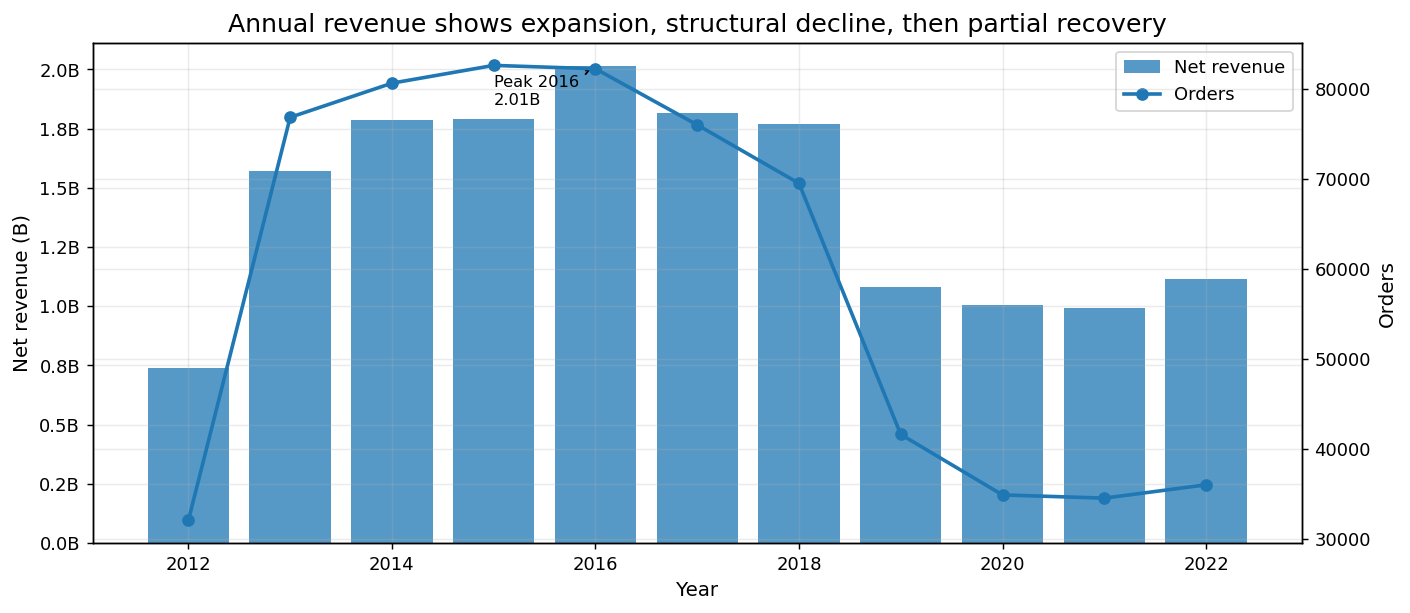

,year,orders,customers,net_revenue,adjusted_revenue,discount,refund,margin,gross_margin_pct,yoy_revenue_%
0,2012,32051,22068,"741,497,748.02","717,888,351.35",0.00,"23,609,396.67","149,142,357.64",20.11,NaN
1,2013,76849,39384,"1,570,165,168.70","1,518,168,680.27","87,004,248.57","51,996,488.43","101,601,584.35",6.47,111.76
2,2014,80645,40376,"1,785,342,715.14","1,727,097,701.62","86,503,167.66","58,245,013.52","204,428,115.72",11.45,13.70
3,2015,82622,40807,"1,792,009,966.56","1,731,442,469.52","97,923,860.36","60,567,497.04","122,718,888.87",6.85,0.37
4,2016,82247,40933,"2,012,364,465.62","1,946,027,527.09","92,276,211.92","66,336,938.53","225,053,644.45",11.18,12.30
5,2017,76010,39651,"1,815,546,633.98","1,756,534,447.45","95,617,691.30","59,012,186.53","118,493,790.78",6.53,-9.78
6,2018,69510,37922,"1,769,723,179.62","1,713,503,920.56","80,399,276.46","56,219,259.06","220,990,372.30",12.49,-2.52
7,2019,41601,27312,"1,081,589,581.19","1,046,458,839.65","55,211,860.32","35,130,741.54","73,957,582.40",6.84,-38.88
8,2020,34881,24335,"1,006,108,536.38","973,702,452.07","48,403,622.41","32,406,084.31","116,352,405.06",11.56,-6.98
9,2021,34525,23984,"991,214,173.72","958,760,588.32","51,825,645.91","32,453,585.40","48,885,841.28",4.93,-1.48


In [186]:
annual = orders_master.groupby('year').agg(
    orders=('order_id', 'count'),
    customers=('customer_id', 'nunique'),
    net_revenue=('net_revenue', 'sum'),
    adjusted_revenue=('adjusted_revenue', 'sum'),
    discount=('discount_amount', 'sum'),
    refund=('refund_amount', 'sum'),
    margin=('gross_margin', 'sum')
).reset_index()
annual['gross_margin_pct'] = annual['margin'] / annual['net_revenue'] * 100
annual['yoy_revenue_%'] = annual['net_revenue'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(annual['year'], annual['net_revenue'] / 1e9, alpha=0.75, label='Net revenue')
ax1.set_ylabel('Net revenue (B)')
ax1.set_xlabel('Year')
ax1.set_title('Annual revenue shows expansion, structural decline, then partial recovery')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1f}B'))

ax2 = ax1.twinx()
ax2.plot(annual['year'], annual['orders'], marker='o', linewidth=2, label='Orders')
ax2.set_ylabel('Orders')

peak_year = annual.loc[annual['net_revenue'].idxmax(), 'year']
peak_rev = annual['net_revenue'].max() / 1e9
ax1.annotate(f'Peak {peak_year}\n{peak_rev:.2f}B', xy=(peak_year, peak_rev), xytext=(peak_year-1, peak_rev*0.92),
             arrowprops=dict(arrowstyle='->', lw=1), fontsize=9)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')
plt.show()

display(annual.round(2))

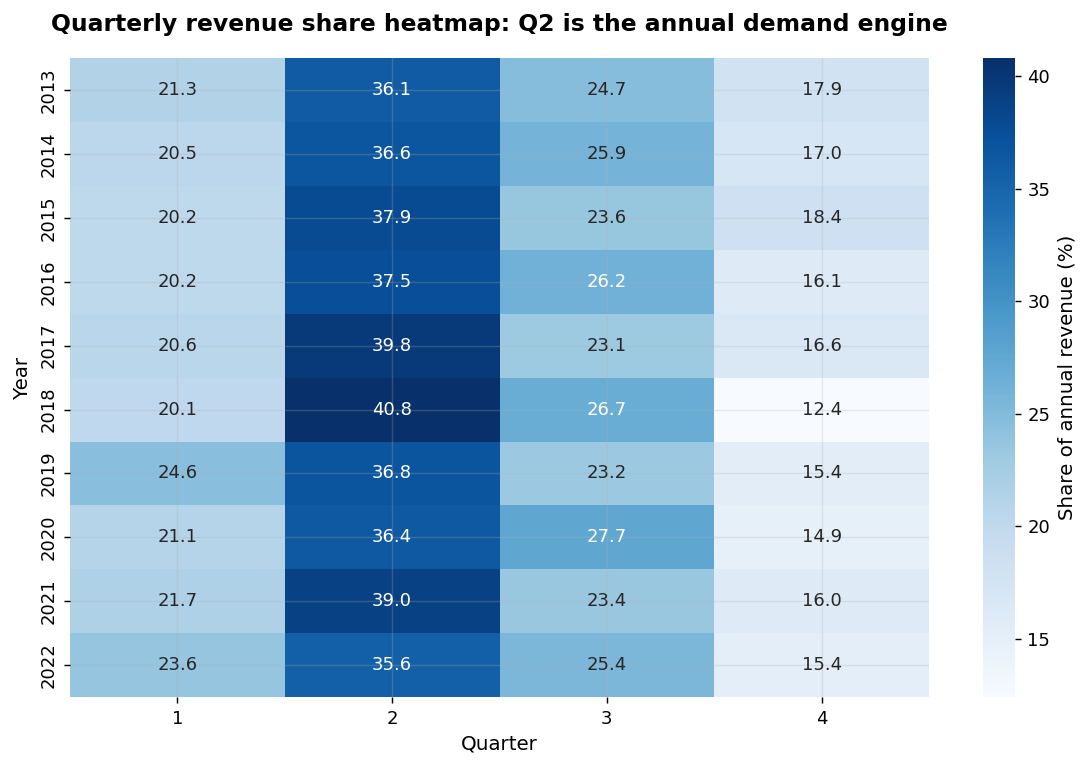

,quarter,avg_revenue_share,avg_daily_revenue,avg_margin
0,1,21.38,"3,672,733.41",16.66
1,2,37.63,"6,512,524.43",17.10
2,3,24.99,"4,265,146.84",5.06
3,4,16.01,"2,745,723.13",11.85


In [187]:
if USE_SALES_FOR_CONTEXT and sales_daily is not None:
    calendar = sales_daily.rename(columns={'Revenue': 'revenue', 'COGS': 'cogs'})[['date', 'revenue', 'cogs']].copy()
    calendar['year'] = calendar['date'].dt.year
    calendar['month'] = calendar['date'].dt.month
    calendar['quarter'] = calendar['date'].dt.quarter
else:
    calendar = daily_orders.rename(columns={'net_revenue': 'revenue'})[['date', 'revenue']].copy()
    calendar['cogs'] = np.nan
    calendar['year'] = calendar['date'].dt.year
    calendar['month'] = calendar['date'].dt.month
    calendar['quarter'] = calendar['date'].dt.quarter

# Remove 2012 (incomplete year)
calendar_full_years = calendar[calendar['year'] >= 2013].copy()
quarter = calendar_full_years.groupby(['year', 'quarter']).agg(
    revenue=('revenue', 'sum'),
    daily_revenue=('revenue', 'mean'),
    cogs=('cogs', 'sum')
).reset_index()
quarter['annual_revenue'] = quarter.groupby('year')['revenue'].transform('sum')
quarter['share_of_year_%'] = quarter['revenue'] / quarter['annual_revenue'] * 100
quarter['margin_%'] = np.where(quarter['cogs'].notna(), (quarter['revenue'] - quarter['cogs']) / quarter['revenue'] * 100, np.nan)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    pivot_q, 
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={'label': 'Share of annual revenue (%)'},
    ax=ax
)
ax.set_title('Quarterly revenue share heatmap: Q2 is the annual demand engine', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Quarter')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

q_summary = quarter.groupby('quarter').agg(
    avg_revenue_share=('share_of_year_%', 'mean'),
    avg_daily_revenue=('daily_revenue', 'mean'),
    avg_margin=('margin_%', 'mean')
).reset_index()
display(q_summary.round(2))

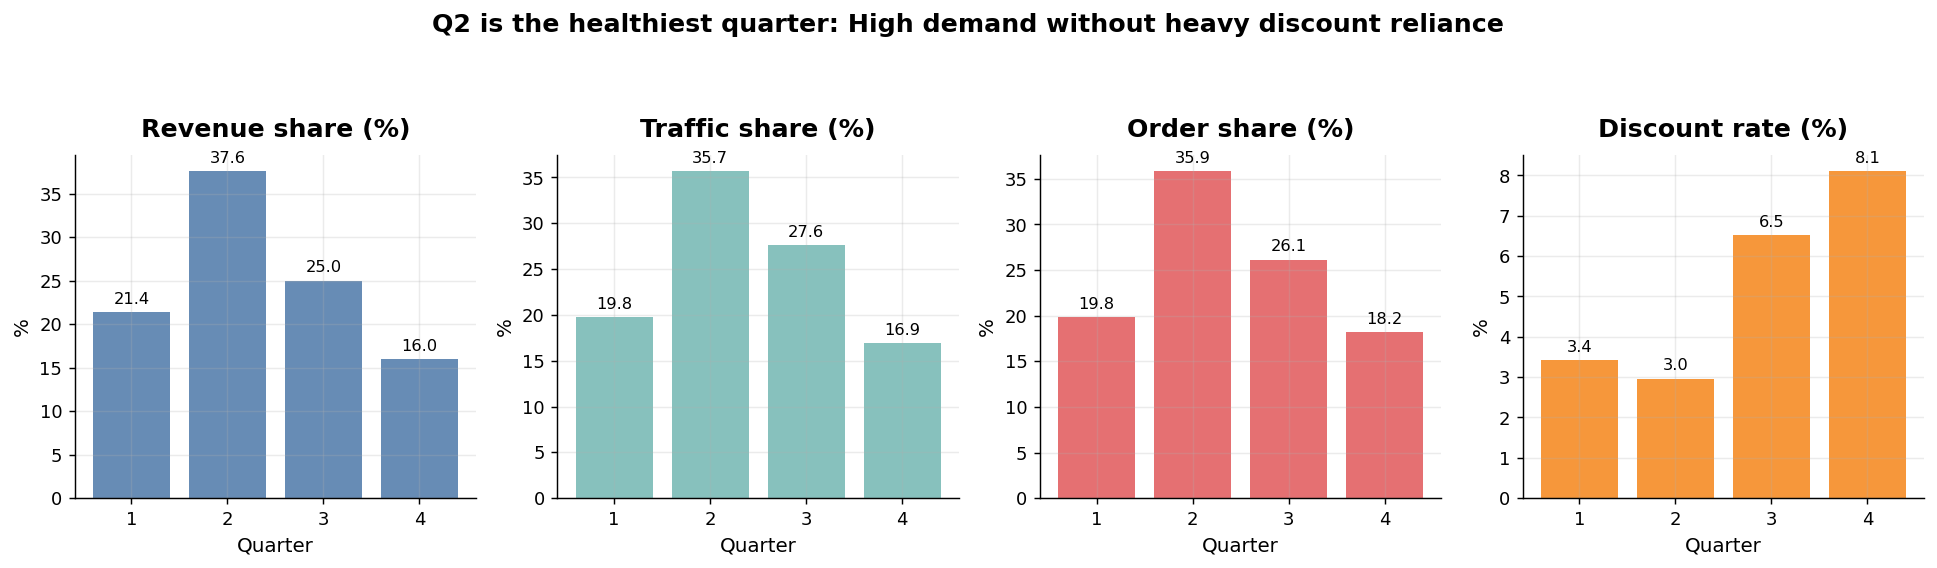

,quarter,avg_revenue_share,session_share_%,order_share_%,discount_rate_%,margin_%
0,1,21.38,19.75,19.83,3.41,13.34
1,2,37.63,35.71,35.87,2.96,14.22
2,3,24.99,27.59,26.13,6.52,-0.43
3,4,16.01,16.95,18.17,8.11,4.10


In [188]:
# Q2 triangulation: revenue, order volume, traffic, discount, margin
orders_q = orders_master[orders_master['year'] >= 2013].groupby('quarter').agg(
    orders=('order_id', 'count'),
    net_revenue=('net_revenue', 'sum'),
    gross_revenue=('gross_revenue', 'sum'),
    discount=('discount_amount', 'sum'),
    margin=('gross_margin', 'sum')
).reset_index()

orders_q['discount_rate_%'] = (orders_q['discount'] / orders_q['gross_revenue']) * 100
orders_q['margin_%'] = (orders_q['margin'] / orders_q['net_revenue']) * 100
orders_q['order_share_%'] = (orders_q['orders'] / orders_q['orders'].sum()) * 100

traffic_q = web_traffic[web_traffic['date'].dt.year >= 2013].assign(
    quarter=lambda x: x['date'].dt.quarter
).groupby('quarter').agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum')
).reset_index()

traffic_q['session_share_%'] = (traffic_q['sessions'] / traffic_q['sessions'].sum()) * 100

q_merged = q_summary.merge(orders_q, on='quarter').merge(traffic_q, on='quarter')

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
metrics = [
    ('avg_revenue_share', 'Revenue share (%)', '#4C78A8'),
    ('session_share_%', 'Traffic share (%)', '#72B7B2'),
    ('order_share_%', 'Order share (%)', '#E15759'),
    ('discount_rate_%', 'Discount rate (%)', '#F58518'),
]

for ax, (col, title, color) in zip(axes, metrics):
    bars = ax.bar(q_merged['quarter'].astype(str), q_merged[col], color=color, alpha=0.85)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('Quarter')
    ax.set_ylabel('%')
    
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Q2 is the healthiest quarter: High demand without heavy discount reliance', y=1.08, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

display(q_merged[['quarter', 'avg_revenue_share', 'session_share_%', 'order_share_%', 'discount_rate_%', 'margin_%']].round(2))

In [189]:
q2_share = q_summary.loc[q_summary['quarter'].eq(2), 'avg_revenue_share'].iloc[0]
q2_daily = q_summary.loc[q_summary['quarter'].eq(2), 'avg_daily_revenue'].iloc[0]
q2_session = q_engine.loc[q_engine['quarter'].eq(2), 'session_share_%'].iloc[0]
q2_discount = q_engine.loc[q_engine['quarter'].eq(2), 'discount_rate_%'].iloc[0]
q2_margin = q_engine.loc[q_engine['quarter'].eq(2), 'margin_%'].iloc[0]

insight_box(
    'Insight 1 — Q2 is the firm\'s harvest quarter',
    'The charts compare annual growth and quarterly seasonality across revenue, traffic, order volume, discounting, and margin.',
    [
        f'Q2 contributes about {q2_share:.1f}% of annual revenue on average, far above a normal 25% quarterly share.',
        f'Average Q2 daily revenue is around {fmt_vnd_millions(q2_daily)}, the strongest of all quarters.',
        f'Q2 also captures around {q2_session:.1f}% of annual web sessions, confirming that the demand surge starts before checkout.',
        f'Q2 discount rate is only around {q2_discount:.1f}%, while its margin remains around {q2_margin:.1f}%; this is healthier than Q3/Q4 promotion-led demand.'
    ],
    [
        'For a Vietnamese fashion ecommerce context, Q2 likely captures spring-to-summer wardrobe refresh, 30/4-1/5 holiday shopping, travel demand, and the start of summer consumption.',
        'The business should not treat all quarters equally. Q2 is the season where stockouts, slow delivery, or weak campaign execution are most expensive.'
    ],
    [
        'Pre-build inventory and fulfillment capacity from late February to March.',
        'Use moderate Q2 promotions to capture demand, but avoid deep markdowns because customers already show high natural buying intent.',
        'Use Q2 as the benchmark for healthy growth: high traffic, high volume, controlled discounting, stronger margin.'
    ]
)

### Insight 1 — Q2 is the firm's harvest quarter

**What the chart shows:** The charts compare annual growth and quarterly seasonality across revenue, traffic, order volume, discounting, and margin.

**Key findings:**
- Q2 contributes about 37.6% of annual revenue on average, far above a normal 25% quarterly share.
- Average Q2 daily revenue is around 6.5M, the strongest of all quarters.
- Q2 also captures around 35.7% of annual web sessions, confirming that the demand surge starts before checkout.
- Q2 discount rate is only around 3.0%, while its margin remains around 14.2%; this is healthier than Q3/Q4 promotion-led demand.

**Business implications:**
- For a Vietnamese fashion ecommerce context, Q2 likely captures spring-to-summer wardrobe refresh, 30/4-1/5 holiday shopping, travel demand, and the start of summer consumption.
- The business should not treat all quarters equally. Q2 is the season where stockouts, slow delivery, or weak campaign execution are most expensive.

**Recommended actions:**
- Pre-build inventory and fulfillment capacity from late February to March.
- Use moderate Q2 promotions to capture demand, but avoid deep markdowns because customers already show high natural buying intent.
- Use Q2 as the benchmark for healthy growth: high traffic, high volume, controlled discounting, stronger margin.


## 5. Demand engine: traffic, channels, and customer acquisition quality

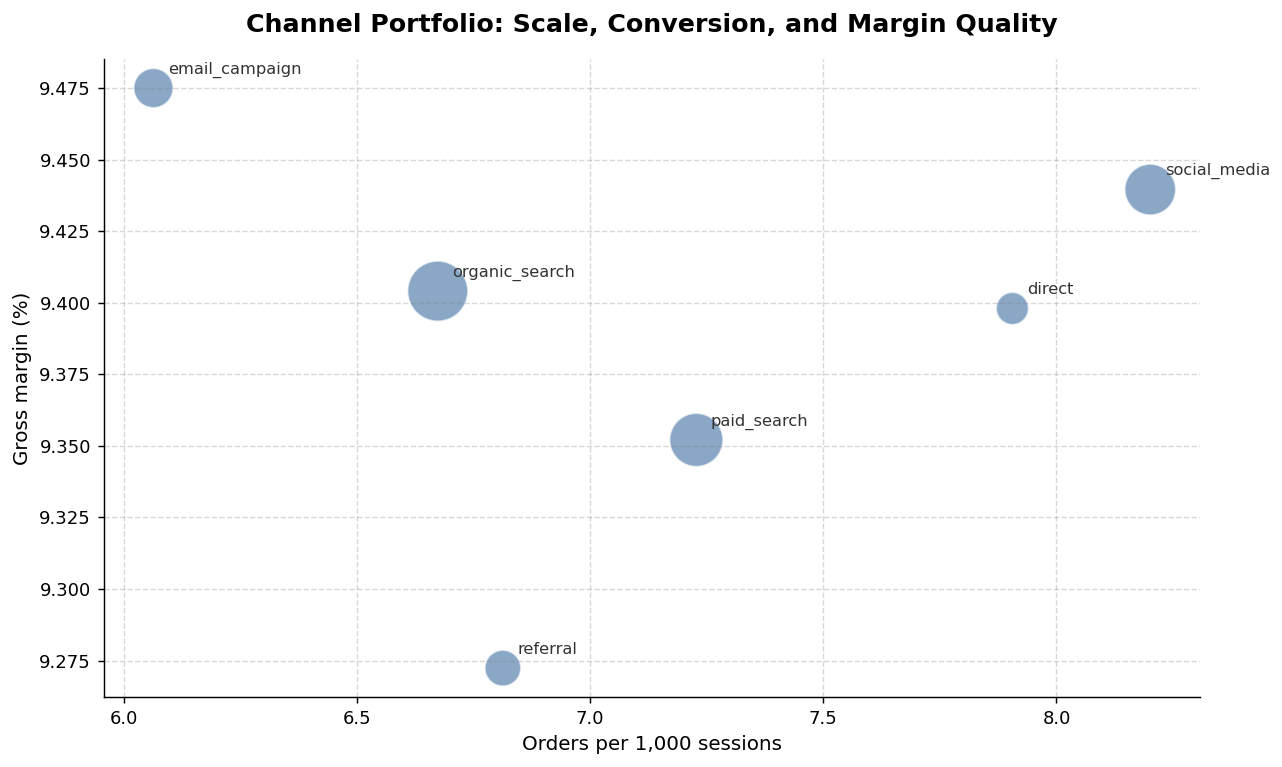

In [190]:
# Traffic source
traffic_source = web_traffic.groupby('traffic_source').agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    page_views=('page_views', 'sum'),
    bounce_rate=('bounce_rate', 'mean'),
    avg_session_duration_sec=('avg_session_duration_sec', 'mean')
).reset_index()

traffic_source['session_share_%'] = (traffic_source['sessions'] / traffic_source['sessions'].sum()) * 100

order_source = orders_master.groupby('order_source').agg(
    orders=('order_id', 'count'),
    revenue=('net_revenue', 'sum'),
    margin=('gross_margin', 'sum'),
    refunds=('refund_amount', 'sum'),
    customers=('customer_id', 'nunique'),
    return_rate=('has_return', 'mean')
).reset_index().rename(columns={'order_source': 'traffic_source'})

order_source['revenue_share_%'] = (order_source['revenue'] / order_source['revenue'].sum()) * 100
order_source['margin_%'] = (order_source['margin'] / order_source['revenue']) * 100
order_source['return_rate_%'] = order_source['return_rate'] * 100
order_source = order_source.drop(columns=['return_rate'])

channel = traffic_source.merge(order_source, on='traffic_source', how='outer').fillna(0)
channel['orders_per_1k_sessions'] = (channel['orders'] / channel['sessions']) * 1000
channel['revenue_per_session'] = channel['revenue'] / channel['sessions']
channel = channel.sort_values('revenue', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

bubble_sizes = channel['revenue_share_%'] * 40

ax.scatter(
    channel['orders_per_1k_sessions'], 
    channel['margin_%'], 
    s=bubble_sizes, 
    alpha=0.65,
    color='#4C78A8',
    edgecolors='white'
)

for x, y, label in zip(channel['orders_per_1k_sessions'], channel['margin_%'], channel['traffic_source']):
    ax.annotate(
        label, 
        (x, y), 
        xytext=(8, 8),
        textcoords='offset points', 
        fontsize=9, 
        fontweight='500', 
        color='#333333'
    )

ax.set_title('Channel Portfolio: Scale, Conversion, and Margin Quality', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Orders per 1,000 sessions')
ax.set_ylabel('Gross margin (%)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

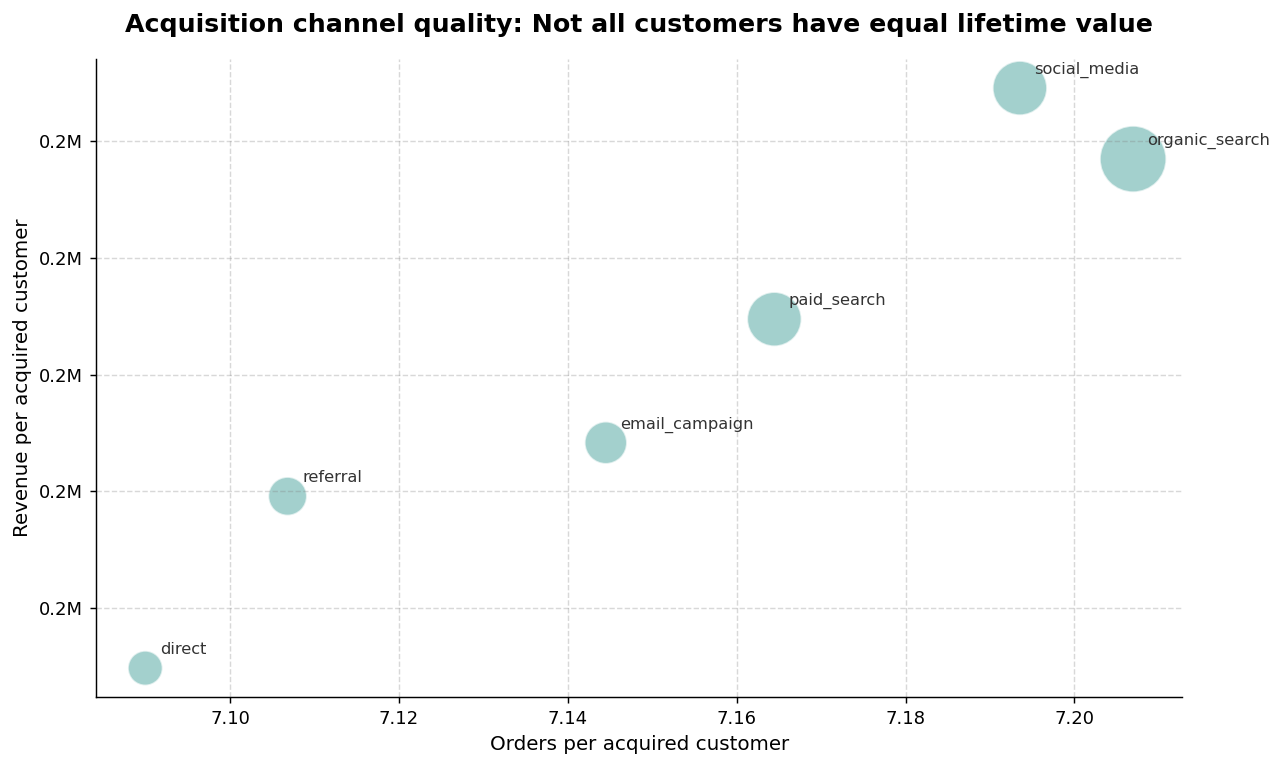

,acquisition_channel,customers,orders_per_customer,revenue_per_customer,margin_%,return_rate_%
5,social_media,18002,7.19,"175,458.14",9.58,5.51
2,organic_search,26950,7.21,"174,849.29",9.28,5.59
3,paid_search,17999,7.16,"173,475.16",9.51,5.57
1,email_campaign,10886,7.14,"172,414.69",9.42,5.72
4,referral,9072,7.11,"171,955.64",9.18,5.45
0,direct,7337,7.09,"170,480.62",9.28,5.61


In [191]:
# Acquisition channel quality
acq = orders_master.groupby('acquisition_channel').agg(
    orders=('order_id', 'count'),
    customers=('customer_id', 'nunique'),
    revenue=('net_revenue', 'sum'),
    margin=('gross_margin', 'sum'),
    refunds=('refund_amount', 'sum'),
    return_rate=('has_return', 'mean')
).reset_index()

acq['orders_per_customer'] = acq['orders'] / acq['customers']
acq['revenue_per_customer'] = acq['revenue'] / acq['customers']
acq['margin_%'] = (acq['margin'] / acq['revenue']) * 100
acq['return_rate_%'] = acq['return_rate'] * 100
acq = acq.drop(columns=['return_rate']).sort_values('revenue_per_customer', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

bubble_sizes = acq['customers'] / 20

ax.scatter(
    acq['orders_per_customer'], 
    acq['revenue_per_customer'], 
    s=bubble_sizes, 
    alpha=0.65,
    color='#72B7B2', # Giving this a distinct color from the traffic chart
    edgecolors='white'
)

for x, y, label in zip(acq['orders_per_customer'], acq['revenue_per_customer'], acq['acquisition_channel']):
    ax.annotate(
        label, 
        (x, y), 
        xytext=(8, 8), 
        textcoords='offset points', 
        fontsize=9, 
        fontweight='500',
        color='#333333'
    )

ax.set_title('Acquisition channel quality: Not all customers have equal lifetime value', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Orders per acquired customer')
ax.set_ylabel('Revenue per acquired customer')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: fmt_vnd_millions(x)))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

display_cols = ['acquisition_channel', 'customers', 'orders_per_customer', 'revenue_per_customer', 'margin_%', 'return_rate_%']
display(acq[display_cols].round(2))

In [192]:
best_acq = acq.iloc[0]
worst_acq = acq.iloc[-1]
insight_box(
    'Insight 2 — Growth should be measured by customer quality, not only by traffic volume',
    'The channel charts combine web sessions, orders, revenue, margin, returns, and customer acquisition source.',
    [
        f'{best_acq.acquisition_channel} has the highest revenue per acquired customer at roughly {fmt_vnd_millions(best_acq.revenue_per_customer)}.',
        f'{worst_acq.acquisition_channel} is the weakest by revenue per customer at roughly {fmt_vnd_millions(worst_acq.revenue_per_customer)}.',
        'Organic search, paid search, and social media are the largest order sources; the difference between them is less about AOV and more about scale and customer mix.'
    ],
    [
        'The firm should not simply buy more visits. It should fund channels that create repeat customers and protect margin.',
        'Vietnamese ecommerce customers often switch channels quickly across social, search, and direct; this makes channel quality monitoring more useful than last-click revenue alone.'
    ],
    [
        'Create a monthly channel scorecard using: revenue per customer, orders per customer, margin %, and return rate.',
        'Use social/search for Q2 demand capture, but retarget high-value cohorts into email/direct to reduce paid-media dependence.',
        'Shift budget away from sources that generate low repeat value or high refund pressure, even if they look strong on first-order revenue.'
    ]
)

### Insight 2 — Growth should be measured by customer quality, not only by traffic volume

**What the chart shows:** The channel charts combine web sessions, orders, revenue, margin, returns, and customer acquisition source.

**Key findings:**
- social_media has the highest revenue per acquired customer at roughly 0.2M.
- direct is the weakest by revenue per customer at roughly 0.2M.
- Organic search, paid search, and social media are the largest order sources; the difference between them is less about AOV and more about scale and customer mix.

**Business implications:**
- The firm should not simply buy more visits. It should fund channels that create repeat customers and protect margin.
- Vietnamese ecommerce customers often switch channels quickly across social, search, and direct; this makes channel quality monitoring more useful than last-click revenue alone.

**Recommended actions:**
- Create a monthly channel scorecard using: revenue per customer, orders per customer, margin %, and return rate.
- Use social/search for Q2 demand capture, but retarget high-value cohorts into email/direct to reduce paid-media dependence.
- Shift budget away from sources that generate low repeat value or high refund pressure, even if they look strong on first-order revenue.


## 6. Assortment economics: category, segment, margin, and product-quality signals

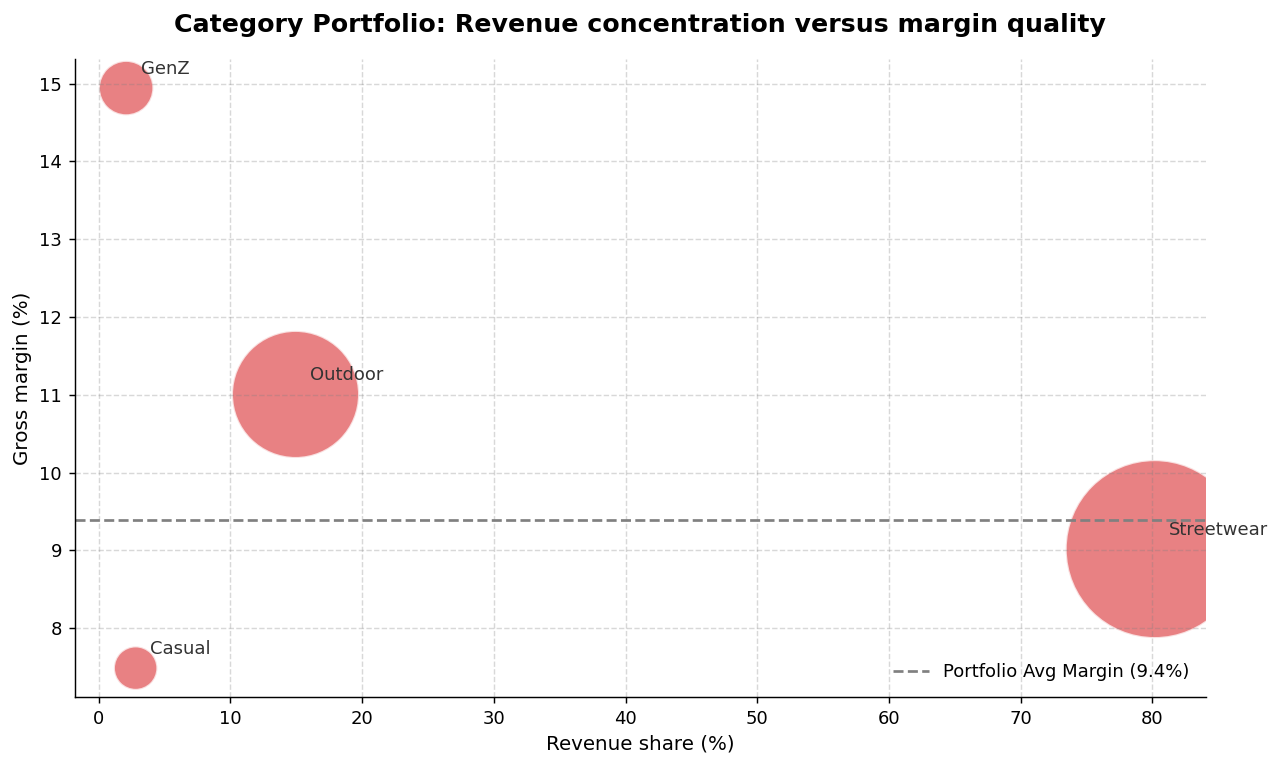

,dominant_category,revenue_share_%,margin_%,return_rate_%,discount_rate_%,avg_rating
3,Streetwear,80.18,9.02,5.54,4.36,3.94
2,Outdoor,14.94,11.00,5.63,5.67,3.93
0,Casual,2.80,7.49,5.40,4.42,3.93
1,GenZ,2.08,14.94,5.71,4.33,3.92


In [193]:
# Category portfolio
category = orders_master.groupby('dominant_category').agg(
    orders=('order_id', 'count'),
    revenue=('net_revenue', 'sum'),
    margin=('gross_margin', 'sum'),
    refunds=('refund_amount', 'sum'),
    discount=('discount_amount', 'sum'),
    avg_rating=('avg_rating', 'mean'),
    return_rate=('has_return', 'mean')
).reset_index()

category['revenue_share_%'] = (category['revenue'] / category['revenue'].sum()) * 100
category['margin_%'] = (category['margin'] / category['revenue']) * 100
category['return_rate_%'] = category['return_rate'] * 100
category['discount_rate_%'] = (category['discount'] / (category['revenue'] + category['discount'])) * 100

category = category.drop(columns=['return_rate']).sort_values('revenue', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

bubble_sizes = category['orders'] / 40

ax.scatter(
    category['revenue_share_%'], 
    category['margin_%'], 
    s=bubble_sizes, 
    alpha=0.75,
    color='#E15759',
    edgecolors='white',
    linewidth=1.2
)

for x, y, label in zip(category['revenue_share_%'], category['margin_%'], category['dominant_category']):
    ax.annotate(
        label, 
        (x, y), 
        fontsize=10, 
        fontweight='500',
        color='#333333',
        xytext=(8, 8), 
        textcoords='offset points'
    )

portfolio_margin = (orders_master['gross_margin'].sum() / orders_master['net_revenue'].sum()) * 100
ax.axhline(portfolio_margin, ls='--', lw=1.5, color='gray', label=f'Portfolio Avg Margin ({portfolio_margin:.1f}%)')

ax.set_title('Category Portfolio: Revenue concentration versus margin quality', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Revenue share (%)')
ax.set_ylabel('Gross margin (%)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='gray', linestyle='--', alpha=0.3)
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
plt.show()

display_cols = ['dominant_category', 'revenue_share_%', 'margin_%', 'return_rate_%', 'discount_rate_%', 'avg_rating']
display(category[display_cols].round(2))

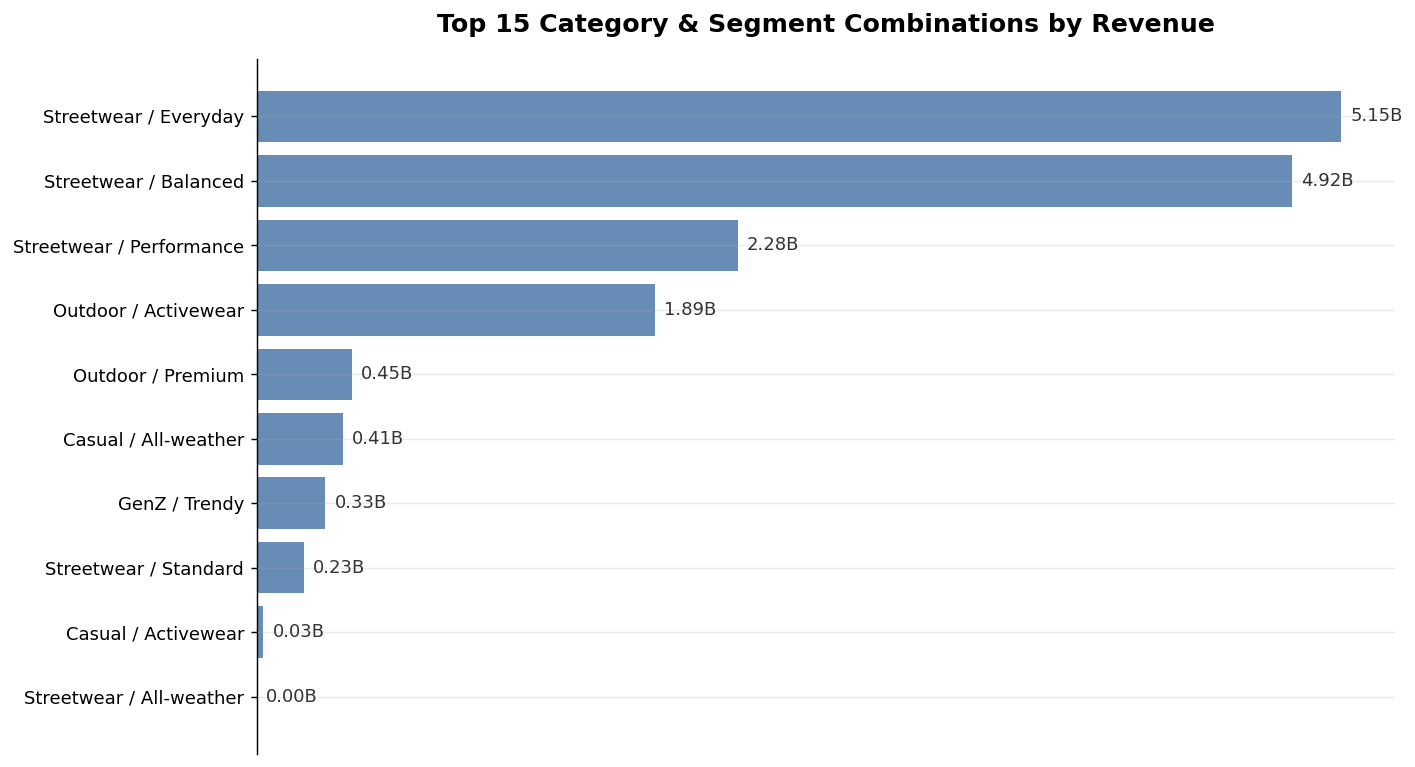

,dominant_category,dominant_segment,orders,revenue,margin_%,return_rate_%,avg_rating
7,Streetwear,Everyday,180118,"5,149,188,323.51",10.04,5.57,3.95
6,Streetwear,Balanced,102608,"4,915,013,162.01",8.54,5.43,3.93
8,Streetwear,Performance,95323,"2,283,654,122.29",7.43,5.63,3.94
3,Outdoor,Activewear,167970,"1,890,121,264.04",12.27,5.65,3.93
4,Outdoor,Premium,30426,"452,541,248.55",5.72,5.55,3.96
1,Casual,All-weather,22230,"407,234,171.55",6.67,5.36,3.93
2,GenZ,Trendy,36441,"325,914,227.49",14.94,5.71,3.92
9,Streetwear,Standard,10790,"225,594,588.03",12.30,5.50,3.93
0,Casual,Activewear,1037,"31,488,597.52",18.02,6.27,3.87
5,Streetwear,All-weather,2,"119,560.44",-5.80,0.00,4.50


In [194]:
# Category and segment
segment = orders_master.groupby(['dominant_category', 'dominant_segment']).agg(
    orders=('order_id', 'count'),
    revenue=('net_revenue', 'sum'),
    margin=('gross_margin', 'sum'),
    refunds=('refund_amount', 'sum'),
    avg_rating=('avg_rating', 'mean'),
    return_rate=('has_return', 'mean')
).reset_index()

segment['margin_%'] = (segment['margin'] / segment['revenue']) * 100
segment['return_rate_%'] = segment['return_rate'] * 100
segment = segment.drop(columns=['return_rate'])
segment_top = segment.sort_values('revenue', ascending=False).head(15).copy()
segment_top['label'] = segment_top['dominant_category'] + ' / ' + segment_top['dominant_segment']
plot_df = segment_top.sort_values('revenue', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(plot_df['label'], plot_df['revenue'] / 1e9, color='#4C78A8', alpha=0.85)

ax.set_title('Top 15 Category & Segment Combinations by Revenue', fontsize=14, fontweight='bold', pad=15)
ax.bar_label(bars, fmt='%.2fB', padding=5, fontsize=10, color='#333333')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.xaxis.set_visible(False) 

plt.tight_layout()
plt.show()

display_cols = ['dominant_category', 'dominant_segment', 'orders', 'revenue', 'margin_%', 'return_rate_%', 'avg_rating']
display(segment_top[display_cols].round(2))

In [195]:
cat_leader = category.iloc[0]
best_margin_cat = category.sort_values('margin_%', ascending=False).iloc[0]
insight_box(
    'Insight 3 — The assortment is revenue-concentrated, so category mistakes are high-risk',
    'The category portfolio chart compares how much revenue each category contributes against its margin quality, return rate, and discount burden.',
    [
        f'{cat_leader.dominant_category} contributes around {cat_leader["revenue_share_%"]:.1f}% of revenue, making the business highly dependent on one category cluster.',
        f'{best_margin_cat.dominant_category} has the strongest margin profile at around {best_margin_cat["margin_%"]:.1f}%, even if it is smaller in scale.',
        'High revenue concentration means pricing, inventory, and quality issues in the lead category can move total company results.'
    ],
    [
        'The firm should manage assortment like a portfolio: scale categories for revenue, high-margin categories for profit, and high-return categories for quality intervention.',
        'In Vietnamese fashion ecommerce, size/fit and product expectation gaps can quickly create refund leakage if category quality is not controlled.'
    ],
    [
        'Protect the leading category with better demand forecasting and size availability.',
        'Use high-margin smaller categories as profit boosters in bundles and recommendation modules.',
        'Create category-level weekly alerts for margin %, return rate, and rating deterioration.'
    ]
)

### Insight 3 — The assortment is revenue-concentrated, so category mistakes are high-risk

**What the chart shows:** The category portfolio chart compares how much revenue each category contributes against its margin quality, return rate, and discount burden.

**Key findings:**
- Streetwear contributes around 80.2% of revenue, making the business highly dependent on one category cluster.
- GenZ has the strongest margin profile at around 14.9%, even if it is smaller in scale.
- High revenue concentration means pricing, inventory, and quality issues in the lead category can move total company results.

**Business implications:**
- The firm should manage assortment like a portfolio: scale categories for revenue, high-margin categories for profit, and high-return categories for quality intervention.
- In Vietnamese fashion ecommerce, size/fit and product expectation gaps can quickly create refund leakage if category quality is not controlled.

**Recommended actions:**
- Protect the leading category with better demand forecasting and size availability.
- Use high-margin smaller categories as profit boosters in bundles and recommendation modules.
- Create category-level weekly alerts for margin %, return rate, and rating deterioration.


## 7. Promotion economics: revenue lift versus margin leakage

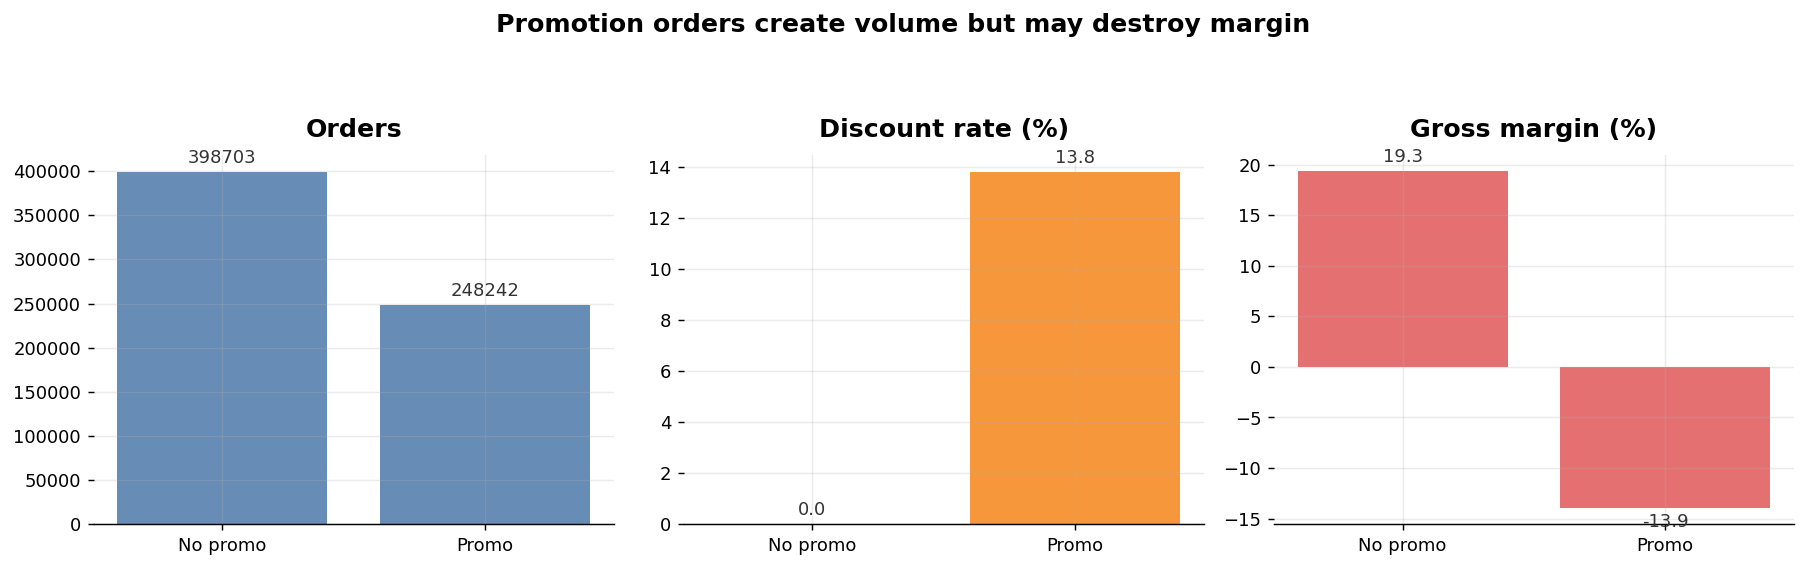

,has_promo,orders,aov,discount_rate_%,margin_%,return_rate_%
0,No promo,398703,"27,565.36",0.00,19.34,5.57
1,Promo,248242,"18,894.78",13.78,-13.91,5.58


In [196]:
# Promotion impact view
promo_summary = orders_master.groupby('has_promo').agg(
    orders=('order_id', 'count'),
    revenue=('net_revenue', 'sum'),
    gross_revenue=('gross_revenue', 'sum'),
    discount=('discount_amount', 'sum'),
    margin=('gross_margin', 'sum'),
    refunds=('refund_amount', 'sum'),
    units=('units', 'sum'),
    return_rate=('has_return', 'mean')
).reset_index()

promo_summary['has_promo'] = promo_summary['has_promo'].map({False: 'No promo', True: 'Promo'})
promo_summary['aov'] = promo_summary['revenue'] / promo_summary['orders']
promo_summary['discount_rate_%'] = (promo_summary['discount'] / promo_summary['gross_revenue']) * 100
promo_summary['margin_%'] = (promo_summary['margin'] / promo_summary['revenue']) * 100
promo_summary['return_rate_%'] = promo_summary['return_rate'] * 100
promo_summary = promo_summary.drop(columns=['return_rate'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = [
    ('orders', 'Orders', '#4C78A8', '%d'), 
    ('discount_rate_%', 'Discount rate (%)', '#F58518', '%.1f'),
    ('margin_%', 'Gross margin (%)', '#E15759', '%.1f')
]

for ax, (col, title, color, fmt) in zip(axes, metrics):
    bars = ax.bar(promo_summary['has_promo'], promo_summary[col], color=color, alpha=0.85)
    ax.set_title(title, fontweight='bold', pad=10)
    
    ax.bar_label(bars, fmt=fmt, padding=3, fontsize=10, color='#333333')
    
    ax.spines[['top', 'right', 'left']].set_visible(False)

plt.suptitle('Promotion orders create volume but may destroy margin', y=1.08, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

display_cols = ['has_promo', 'orders', 'aov', 'discount_rate_%', 'margin_%', 'return_rate_%']
display(promo_summary[display_cols].round(2))

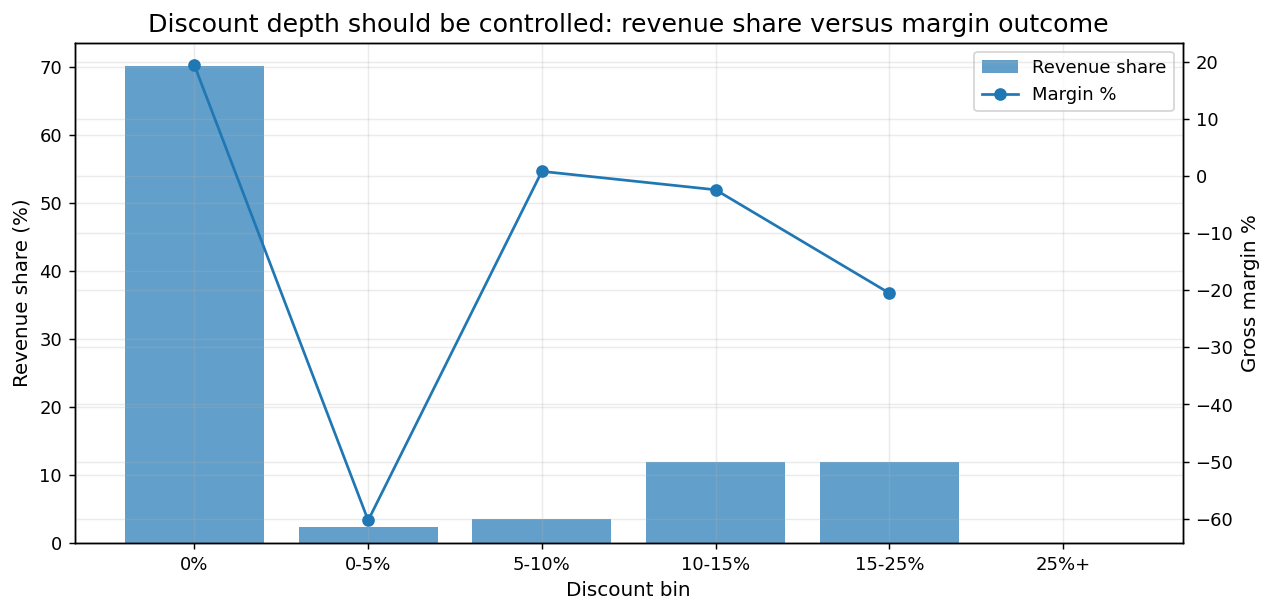

,discount_bin,orders,revenue,margin,refunds,margin_%,return_rate_%,revenue_share_%
0,0%,398703,"10,990,390,489.76","2,125,604,784.24","342,362,146.71",19.34,5.57,70.09
1,0-5%,20689,"375,831,789.26","-226,643,767.41","11,780,608.38",-60.30,5.63,2.40
2,5-10%,24149,"562,442,191.43","4,447,695.24","18,790,732.15",0.79,5.73,3.59
3,10-15%,86925,"1,878,475,672.40","-45,713,960.53","66,154,921.63",-2.43,5.61,11.98
4,15-25%,116479,"1,873,729,122.58","-384,537,039.66","71,510,097.68",-20.52,5.51,11.95
5,25%+,0,0.00,0.00,0.00,NaN,NaN,0.00


In [197]:
# Discount bins
bins = [-0.001, 0, 5, 10, 15, 25, 100]
labels = ['0%', '0-5%', '5-10%', '10-15%', '15-25%', '25%+']
orders_master['discount_bin'] = pd.cut(orders_master['discount_rate'], bins=bins, labels=labels)

discount_bins = orders_master.groupby('discount_bin').agg(
    orders=('order_id', 'count'),
    revenue=('net_revenue', 'sum'),
    margin=('gross_margin', 'sum'),
    refunds=('refund_amount', 'sum')
).reset_index()
discount_bins['margin_%'] = discount_bins['margin'] / discount_bins['revenue'] * 100
discount_bins['return_rate_%'] = orders_master.groupby('discount_bin')['has_return'].mean().values * 100
discount_bins['revenue_share_%'] = discount_bins['revenue'] / discount_bins['revenue'].sum() * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(discount_bins['discount_bin'].astype(str), discount_bins['revenue_share_%'], alpha=0.70, label='Revenue share')
ax1.set_ylabel('Revenue share (%)')
ax1.set_xlabel('Discount bin')
ax1.set_title('Discount depth should be controlled: revenue share versus margin outcome')
ax2 = ax1.twinx()
ax2.plot(discount_bins['discount_bin'].astype(str), discount_bins['margin_%'], marker='o', label='Margin %')
ax2.set_ylabel('Gross margin %')
lines, labels_ = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_ + labels2, loc='best')
plt.show()

display(discount_bins.round(2))

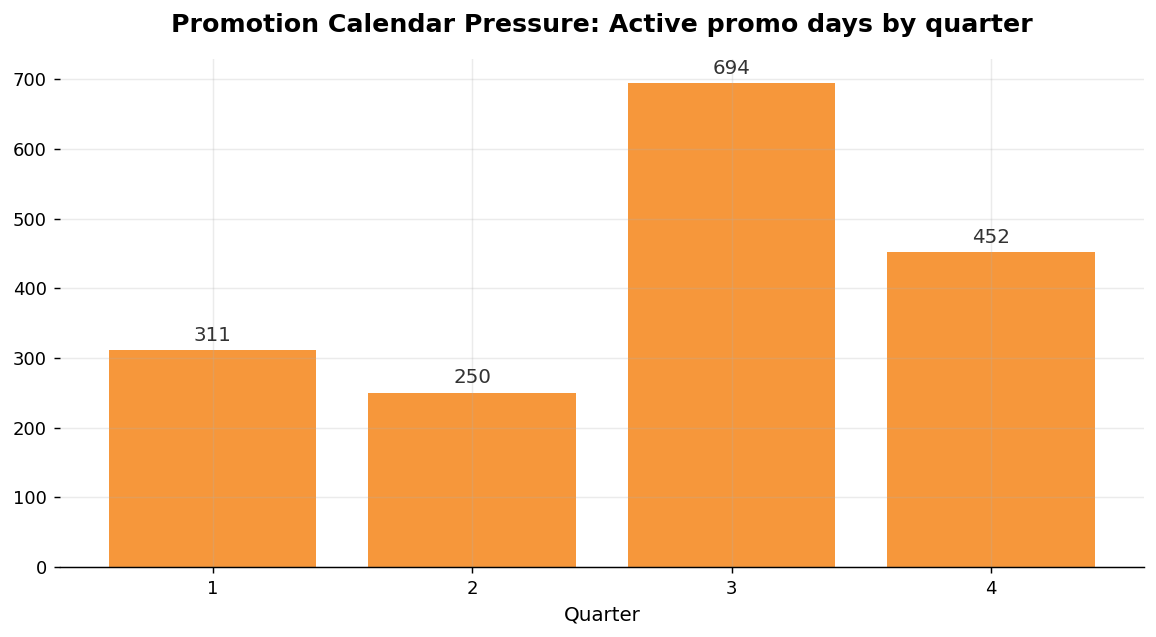

,promo_name,promo_type,discount_value,start_date,end_date,promo_channel
0,Spring Sale 2013,percentage,12.00,2013-03-18,2013-04-17,email
1,Mid-Year Sale 2013,percentage,18.00,2013-06-23,2013-07-22,online
2,Fall Launch 2013,percentage,10.00,2013-08-30,2013-10-02,email
3,Year-End Sale 2013,percentage,20.00,2013-11-18,2014-01-02,all_channels
4,Urban Blowout 2013,fixed,50.00,2013-07-30,2013-09-02,online
5,Rural Special 2013,percentage,15.00,2013-01-31,2013-03-01,in_store
6,Spring Sale 2014,percentage,12.00,2014-03-18,2014-04-17,email
7,Mid-Year Sale 2014,percentage,18.00,2014-06-23,2014-07-22,social_media


In [198]:
# Promotion calendar

promo_calendar = promotions.assign(
    date=[pd.date_range(start, end) for start, end in zip(promotions['start_date'], promotions['end_date'])]
).explode('date').reset_index(drop=True)

promo_calendar['year'] = promo_calendar['date'].dt.year
promo_calendar['quarter'] = promo_calendar['date'].dt.quarter
promo_calendar['month'] = promo_calendar['date'].dt.month

promo_q = promo_calendar.groupby('quarter').agg(
    active_promo_days=('date', 'nunique'),
    active_promos=('promo_id', 'nunique'),
    avg_discount_value=('discount_value', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(promo_q['quarter'].astype(str), promo_q['active_promo_days'], color='#F58518', alpha=0.85)

ax.set_title('Promotion Calendar Pressure: Active promo days by quarter', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quarter')

ax.bar_label(bars, fmt='%d', padding=3, fontsize=11, color='#333333')

ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.show()

display_cols = ['promo_name', 'promo_type', 'discount_value', 'start_date', 'end_date', 'promo_channel']
display(promotions[display_cols].head(8))

In [199]:
promo_row = promo_summary[promo_summary['has_promo'].eq('Promo')].iloc[0]
no_promo_row = promo_summary[promo_summary['has_promo'].eq('No promo')].iloc[0]
qdisc = orders_master.groupby('quarter').agg(gross=('gross_revenue', 'sum'), discount=('discount_amount', 'sum'))
qdisc['discount_rate'] = qdisc['discount'] / qdisc['gross']
q2_safe_rate = qdisc.loc[2, 'discount_rate'] + 0.01
saving_q3q4 = sum(max(0, (qdisc.loc[q, 'discount_rate'] - q2_safe_rate) * qdisc.loc[q, 'gross']) for q in [3, 4])

insight_box(
    'Insight 4 — Promotions need profit guardrails, not just sales targets',
    'The promotion charts compare promo versus non-promo orders, discount-depth bins, and the campaign calendar.',
    [
        f'Promo orders generate {promo_row.orders:,.0f} orders but show a margin rate of around {promo_row["margin_%"]:.1f}%, versus {no_promo_row["margin_%"]:.1f}% for non-promo orders.',
        f'Promo AOV is roughly {fmt_vnd_millions(promo_row.aov)}, lower than non-promo AOV of {fmt_vnd_millions(no_promo_row.aov)}.',
        f'If Q3/Q4 discount intensity were capped near Q2 discount rate + 1pp, the estimated discount leakage reduction is about {fmt_vnd_millions(saving_q3q4)}.'
    ],
    [
        'Discounting appears to be a volume tool, but excessive discount depth can turn revenue into unprofitable demand.',
        'Q2 is strong with relatively controlled discounting, so it should be treated as the benchmark for healthy demand capture.'
    ],
    [
        'Set campaign approval rules based on expected margin, not only expected revenue.',
        'Use threshold offers, bundles, and free-shipping mechanics before deep product markdowns.',
        'Review Q3/Q4 campaigns: these quarters may need sharper customer targeting rather than broader discounts.'
    ]
)

### Insight 4 — Promotions need profit guardrails, not just sales targets

**What the chart shows:** The promotion charts compare promo versus non-promo orders, discount-depth bins, and the campaign calendar.

**Key findings:**
- Promo orders generate 248,242 orders but show a margin rate of around -13.9%, versus 19.3% for non-promo orders.
- Promo AOV is roughly 0.0M, lower than non-promo AOV of 0.0M.
- If Q3/Q4 discount intensity were capped near Q2 discount rate + 1pp, the estimated discount leakage reduction is about 175.8M.

**Business implications:**
- Discounting appears to be a volume tool, but excessive discount depth can turn revenue into unprofitable demand.
- Q2 is strong with relatively controlled discounting, so it should be treated as the benchmark for healthy demand capture.

**Recommended actions:**
- Set campaign approval rules based on expected margin, not only expected revenue.
- Use threshold offers, bundles, and free-shipping mechanics before deep product markdowns.
- Review Q3/Q4 campaigns: these quarters may need sharper customer targeting rather than broader discounts.


## 8. Returns, reviews, and product experience leakage

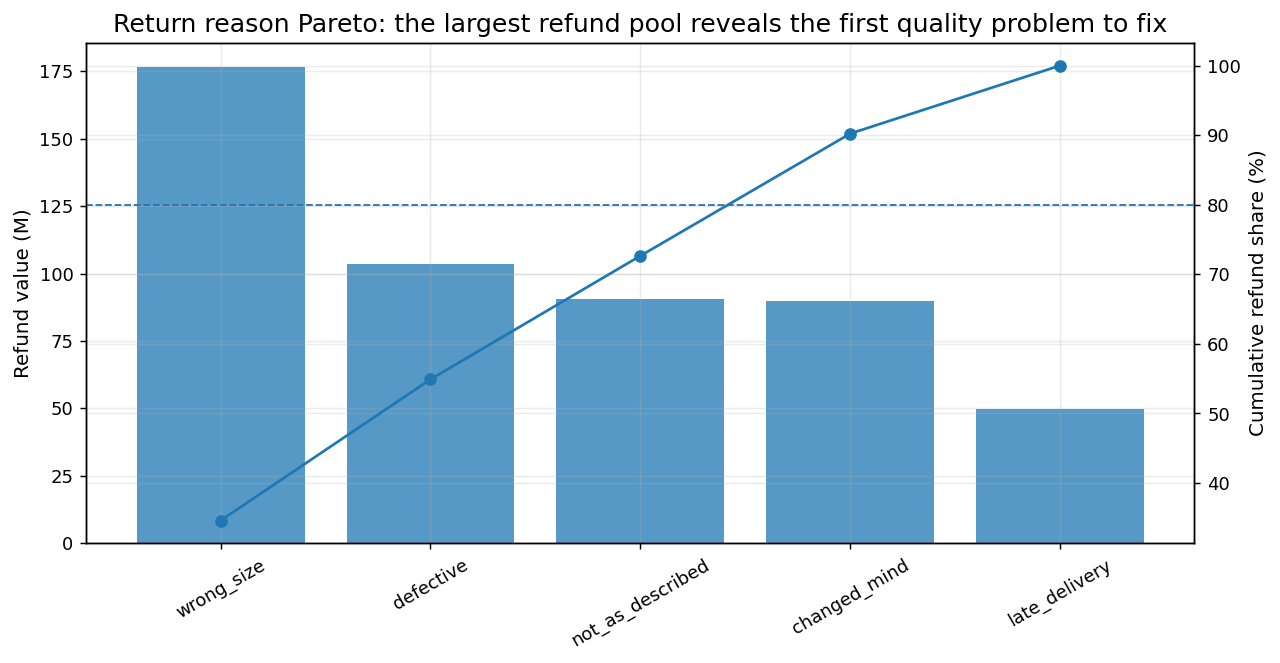

,return_reason,refund,units,return_lines,refund_share_%,cum_refund_share_%
4,wrong_size,"176,745,841.34",38054,13970,34.61,34.61
1,defective,"103,599,143.26",22274,8020,20.29,54.90
3,not_as_described,"90,656,363.23",19361,7036,17.75,72.65
0,changed_mind,"89,721,759.00",19144,6931,17.57,90.22
2,late_delivery,"49,937,212.76",10768,3986,9.78,100.00


In [200]:
returns_enriched = returns.merge(
    items[['order_id', 'product_id', 'category', 'segment']],
    on=['order_id', 'product_id'], how='left'
)

return_reason = returns_enriched.groupby('return_reason').agg(
    refund=('refund_amount', 'sum'),
    units=('return_quantity', 'sum'),
    return_lines=('return_id', 'count')
).reset_index().sort_values('refund', ascending=False)
return_reason['refund_share_%'] = return_reason['refund'] / return_reason['refund'].sum() * 100
return_reason['cum_refund_share_%'] = return_reason['refund_share_%'].cumsum()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(return_reason['return_reason'], return_reason['refund'] / 1e6, alpha=0.75)
ax1.set_ylabel('Refund value (M)')
ax1.set_title('Return reason Pareto: the largest refund pool reveals the first quality problem to fix')
ax1.tick_params(axis='x', rotation=30)
ax2 = ax1.twinx()
ax2.plot(return_reason['return_reason'], return_reason['cum_refund_share_%'], marker='o')
ax2.set_ylabel('Cumulative refund share (%)')
ax2.axhline(80, ls='--', lw=1)
plt.show()

display(return_reason.round(2))

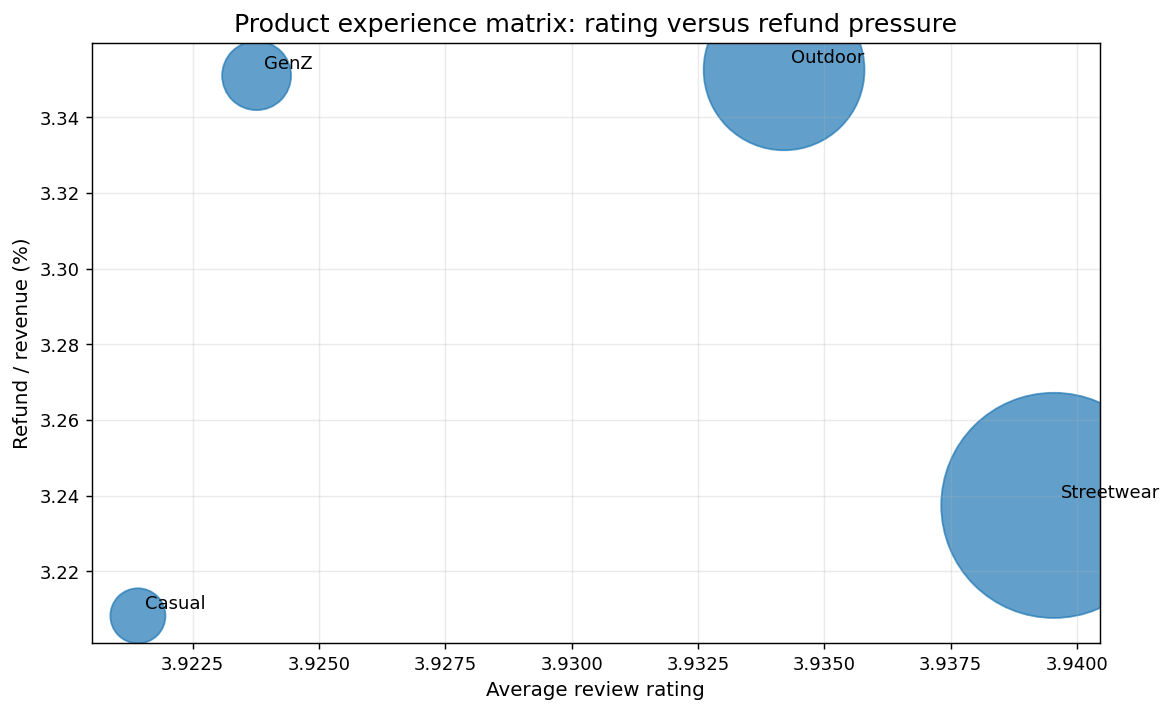

,category,orders,return_rate,refund,revenue,return_rate_%,refund_rate_%,avg_rating,reviews
0,Casual,23267,0.05,"14,075,267.49","438,722,769.07",5.40,3.21,3.92,3894
1,GenZ,36441,0.06,"10,921,573.24","325,914,227.49",5.71,3.35,3.92,5916
2,Outdoor,198396,0.06,"78,539,894.30","2,342,662,512.59",5.63,3.35,3.93,41704
3,Streetwear,388841,0.06,"407,061,771.52","12,573,569,756.28",5.54,3.24,3.94,63265


In [201]:
review_category = items[['order_id', 'category']].drop_duplicates().merge(
    reviews[['order_id', 'rating']], on='order_id', how='inner'
)
review_category = review_category.groupby('category').agg(
    avg_rating=('rating', 'mean'),
    reviews=('rating', 'count')
).reset_index()

cat_return = orders_master.groupby('dominant_category').agg(
    orders=('order_id', 'count'),
    return_rate=('has_return', 'mean'),
    refund=('refund_amount', 'sum'),
    revenue=('net_revenue', 'sum')
).reset_index().rename(columns={'dominant_category': 'category'})
cat_return['return_rate_%'] = cat_return['return_rate'] * 100
cat_return['refund_rate_%'] = cat_return['refund'] / cat_return['revenue'] * 100
cat_quality = cat_return.merge(review_category, on='category', how='left')

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(cat_quality['avg_rating'], cat_quality['refund_rate_%'], s=cat_quality['orders']/25, alpha=0.7)
for _, r in cat_quality.iterrows():
    ax.annotate(r['category'], (r['avg_rating'], r['refund_rate_%']), fontsize=10, xytext=(4, 4), textcoords='offset points')
ax.set_title('Product experience matrix: rating versus refund pressure')
ax.set_xlabel('Average review rating')
ax.set_ylabel('Refund / revenue (%)')
plt.show()

display(cat_quality.round(2))

In [202]:
top_reason = return_reason.iloc[0]
potential_return_saving = top_reason['refund'] * 0.10
insight_box(
    'Insight 5 — Returns are a product-experience problem, not only a logistics problem',
    'The return Pareto and rating/refund matrix connect refund value, return reason, category, and customer review quality.',
    [
        f'The largest return reason is {top_reason.return_reason}, accounting for about {top_reason["refund_share_%"]:.1f}% of refund value.',
        f'A 10% reduction in the largest return reason would protect roughly {fmt_vnd_millions(potential_return_saving)} in refund value.',
        'The return reasons are dominated by product-fit and expectation gaps such as wrong size, defective, and not as described.'
    ],
    [
        'For fashion ecommerce, returns often signal unclear sizing, inconsistent product information, or weak quality control.',
        'Vietnamese online fashion shoppers are sensitive to fit and trust. Better content and size guidance can reduce friction before purchase.'
    ],
    [
        'Prioritize size-guide improvements, model-fit photos, and category-specific size recommendations.',
        'Flag SKUs with high refunds and below-average ratings for product content review or supplier QA.',
        'Use return reason data as a weekly feedback loop to merchandising and product teams, not only customer service.'
    ]
)

### Insight 5 — Returns are a product-experience problem, not only a logistics problem

**What the chart shows:** The return Pareto and rating/refund matrix connect refund value, return reason, category, and customer review quality.

**Key findings:**
- The largest return reason is wrong_size, accounting for about 34.6% of refund value.
- A 10% reduction in the largest return reason would protect roughly 17.7M in refund value.
- The return reasons are dominated by product-fit and expectation gaps such as wrong size, defective, and not as described.

**Business implications:**
- For fashion ecommerce, returns often signal unclear sizing, inconsistent product information, or weak quality control.
- Vietnamese online fashion shoppers are sensitive to fit and trust. Better content and size guidance can reduce friction before purchase.

**Recommended actions:**
- Prioritize size-guide improvements, model-fit photos, and category-specific size recommendations.
- Flag SKUs with high refunds and below-average ratings for product content review or supplier QA.
- Use return reason data as a weekly feedback loop to merchandising and product teams, not only customer service.


## 9. Checkout and payment risk: COD as a business-control issue

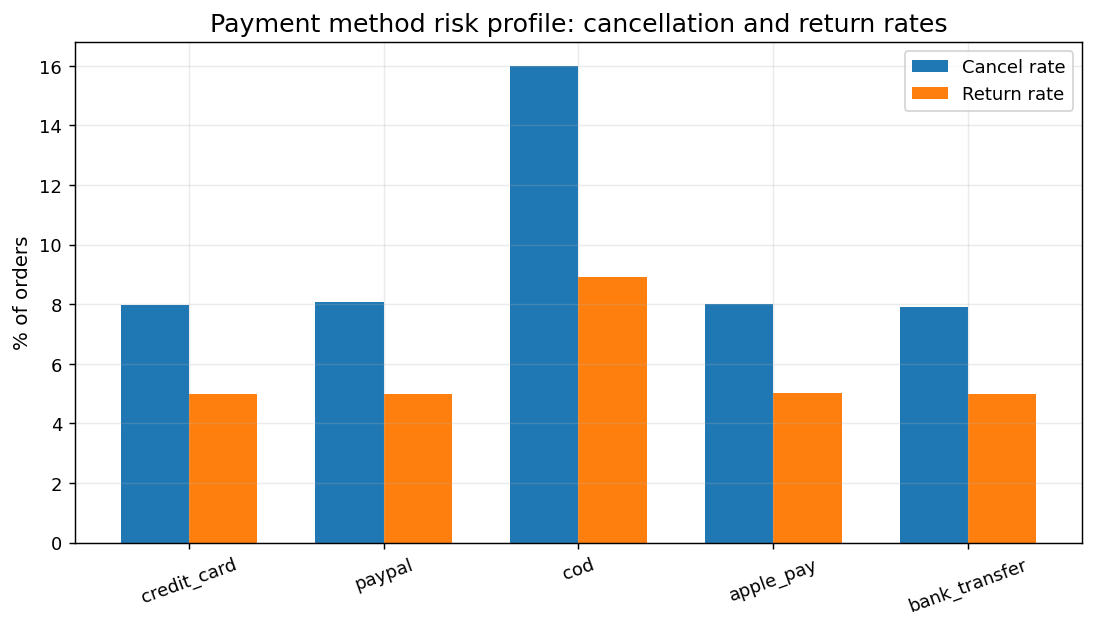

,payment_method,orders,revenue,margin,refunds,avg_installments,return_rate_%,cancel_rate_%,margin_%,revenue_share_%
3,credit_card,356352,"8,630,069,413.19","813,003,306.94","251,417,957.14",3.88,4.99,7.98,9.42,55.04
4,paypal,97018,"2,363,680,137.73","220,235,625.90","68,243,428.78",3.88,4.98,8.06,9.32,15.07
2,cod,96681,"2,346,947,592.93","220,298,873.86","121,469,953.66",1.00,8.90,16.00,9.39,14.97
0,apple_pay,64763,"1,564,269,610.50","146,367,392.13","46,516,773.44",3.88,5.03,8.01,9.36,9.98
1,bank_transfer,32131,"775,902,511.08","73,252,513.04","22,950,393.53",3.85,4.98,7.89,9.44,4.95


In [203]:
payment_col = 'payment_method'
payment = orders_master.groupby(payment_col).agg(
    orders=('order_id', 'count'),
    revenue=('net_revenue', 'sum'),
    margin=('gross_margin', 'sum'),
    refunds=('refund_amount', 'sum'),
    avg_installments=('avg_installments', 'mean')
).reset_index()
payment['return_rate_%'] = orders_master.groupby(payment_col)['has_return'].mean().values * 100
payment['cancel_rate_%'] = orders_master.groupby(payment_col)['is_cancelled'].mean().values * 100
payment['margin_%'] = payment['margin'] / payment['revenue'] * 100
payment['revenue_share_%'] = payment['revenue'] / payment['revenue'].sum() * 100
payment = payment.sort_values('revenue', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(payment))
width = 0.35
ax.bar(x - width/2, payment['cancel_rate_%'], width, label='Cancel rate')
ax.bar(x + width/2, payment['return_rate_%'], width, label='Return rate')
ax.set_xticks(x, payment[payment_col], rotation=20)
ax.set_ylabel('% of orders')
ax.set_title('Payment method risk profile: cancellation and return rates')
ax.legend()
plt.show()

display(payment.round(2))

In [204]:
cod_row = payment[payment[payment_col].eq('cod')].iloc[0] if 'cod' in payment[payment_col].values else payment.sort_values('cancel_rate_%', ascending=False).iloc[0]
non_cod_cancel = payment[~payment[payment_col].eq(cod_row[payment_col])]['cancel_rate_%'].mean()
excess_cancel_orders = max(0, (cod_row['cancel_rate_%'] - non_cod_cancel) / 100 * cod_row['orders'])
est_cancel_revenue = excess_cancel_orders * (cod_row['revenue'] / cod_row['orders'])

insight_box(
    'Insight 6 — COD creates avoidable order-risk exposure',
    'The payment chart compares cancellation and return behavior across payment methods.',
    [
        f'{cod_row[payment_col]} has a cancellation rate of around {cod_row["cancel_rate_%"]:.1f}%, visibly above the non-COD average of around {non_cod_cancel:.1f}%.',
        f'Excess COD cancellation exposure is approximately {excess_cancel_orders:,.0f} orders, equivalent to roughly {fmt_vnd_millions(est_cancel_revenue)} in at-risk order value.',
        'Digital methods such as credit card, bank transfer, wallet, and PayPal are more controlled from an order commitment perspective.'
    ],
    [
        'In Vietnam, COD can help adoption, but it also increases failed delivery, cancellation, and working-capital friction.',
        'The answer is not to remove COD immediately; it is to segment and govern COD usage.'
    ],
    [
        'Introduce COD risk scoring for new customers, high basket values, and historically cancelled accounts.',
        'Offer small incentives for prepaid or wallet payments in high-cancellation segments.',
        'Require confirmation flows for risky COD orders before picking and dispatching inventory.'
    ]
)

### Insight 6 — COD creates avoidable order-risk exposure

**What the chart shows:** The payment chart compares cancellation and return behavior across payment methods.

**Key findings:**
- cod has a cancellation rate of around 16.0%, visibly above the non-COD average of around 8.0%.
- Excess COD cancellation exposure is approximately 7,747 orders, equivalent to roughly 188.1M in at-risk order value.
- Digital methods such as credit card, bank transfer, wallet, and PayPal are more controlled from an order commitment perspective.

**Business implications:**
- In Vietnam, COD can help adoption, but it also increases failed delivery, cancellation, and working-capital friction.
- The answer is not to remove COD immediately; it is to segment and govern COD usage.

**Recommended actions:**
- Introduce COD risk scoring for new customers, high basket values, and historically cancelled accounts.
- Offer small incentives for prepaid or wallet payments in high-cancellation segments.
- Require confirmation flows for risky COD orders before picking and dispatching inventory.


## 10. Fulfillment and geography: cost-to-serve and regional operating discipline

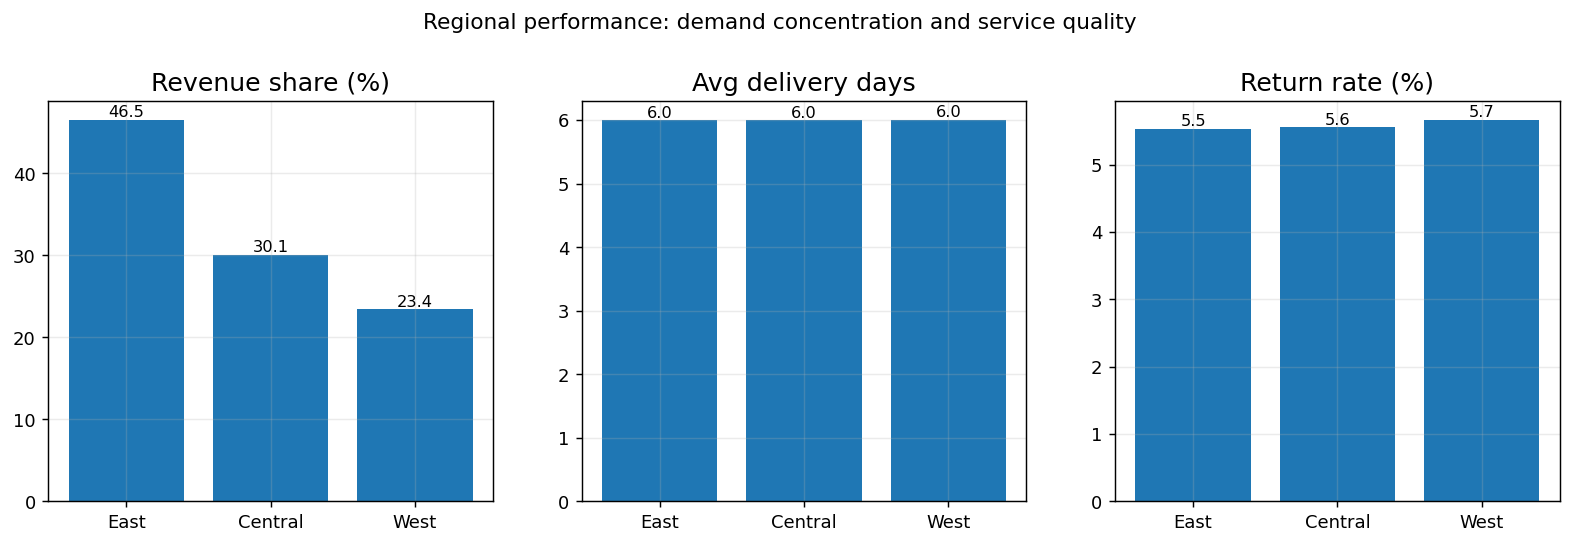

,region,orders,revenue,margin,refunds,shipping_fee,avg_delivery_days,avg_rating,revenue_share_%,return_rate_%,margin_%,shipping_fee_%_revenue
1,East,294612,"7,291,150,819.12","675,822,759.88","235,481,747.98","1,244,288.28",6.00,3.94,46.50,5.54,9.27,0.02
0,Central,184691,"4,719,491,267.84","430,476,527.99","151,387,098.38","773,165.97",6.00,3.95,30.10,5.56,9.12,0.02
2,West,167642,"3,670,227,178.47","366,858,424.00","123,729,660.19","791,855.41",6.00,3.92,23.41,5.66,10.00,0.02


In [205]:
region = orders_master.groupby('region').agg(
    orders=('order_id', 'count'),
    revenue=('net_revenue', 'sum'),
    margin=('gross_margin', 'sum'),
    refunds=('refund_amount', 'sum'),
    shipping_fee=('shipping_fee', 'sum'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_rating=('avg_rating', 'mean')
).reset_index()
region['revenue_share_%'] = region['revenue'] / region['revenue'].sum() * 100
region['return_rate_%'] = orders_master.groupby('region')['has_return'].mean().values * 100
region['margin_%'] = region['margin'] / region['revenue'] * 100
region['shipping_fee_%_revenue'] = region['shipping_fee'] / region['revenue'] * 100
region = region.sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ['revenue_share_%', 'avg_delivery_days', 'return_rate_%'],
    ['Revenue share (%)', 'Avg delivery days', 'Return rate (%)']
):
    ax.bar(region['region'], region[col])
    ax.set_title(title)
    add_bar_labels(ax, fmt='{:.1f}')
    
plt.suptitle('Regional performance: demand concentration and service quality', y=1.05)
plt.show()

display(region.round(2))

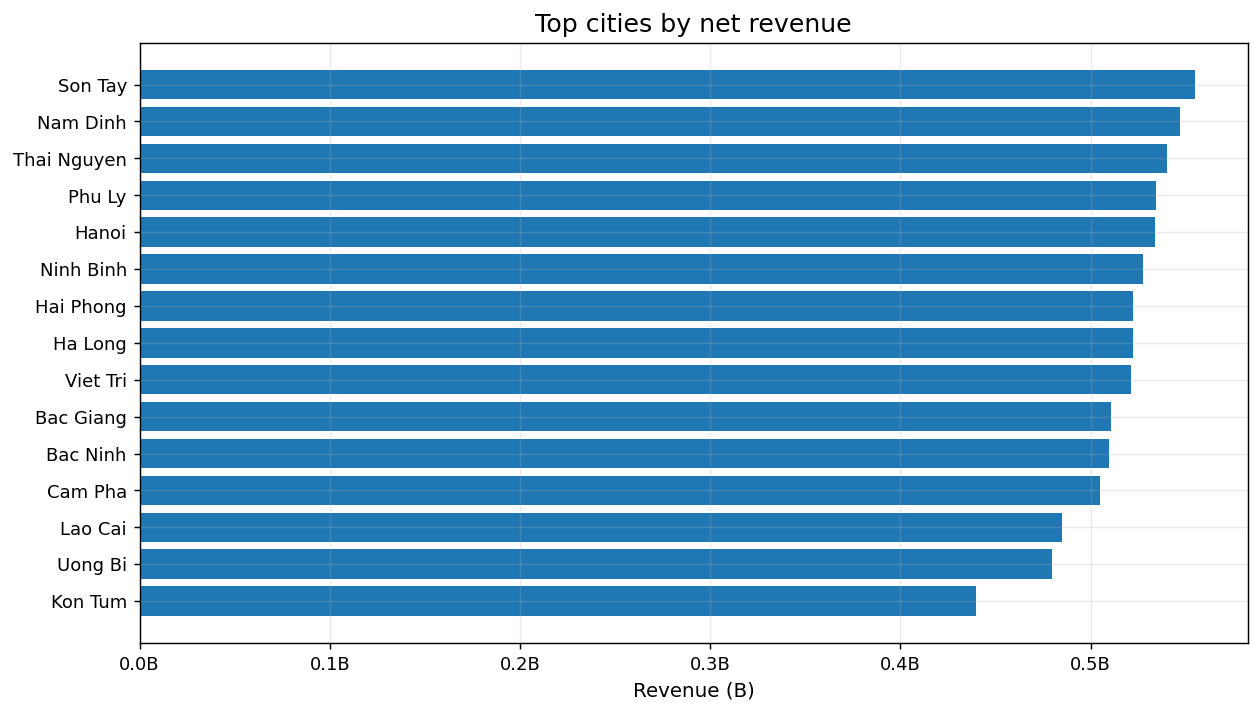

,geo_city,orders,revenue,margin,refunds,avg_delivery_days,margin_%,return_rate_%
33,Son Tay,22473,"554,795,175.01","50,649,151.92","17,357,018.77",6.02,9.13,5.57
22,Nam Dinh,21764,"546,781,717.28","50,793,881.61","16,754,684.78",5.98,9.29,5.52
35,Thai Nguyen,21931,"539,929,108.57","50,834,170.86","18,232,432.33",6.01,9.41,5.68
27,Phu Ly,21330,"534,044,422.31","50,156,626.73","18,251,989.17",5.98,9.39,5.52
14,Hanoi,21576,"533,953,434.21","50,120,143.84","16,580,681.55",6.01,9.39,5.41
24,Ninh Binh,21059,"527,246,875.11","48,501,218.19","16,579,890.60",6.01,9.20,5.55
13,Hai Phong,21087,"522,328,367.98","47,564,288.71","16,642,370.59",6.00,9.11,5.47
12,Ha Long,21043,"522,078,618.77","47,949,837.66","17,380,841.62",5.99,9.18,5.55
39,Viet Tri,20889,"520,904,352.05","50,714,207.73","16,399,680.07",5.99,9.74,5.71
0,Bac Giang,20848,"510,589,604.56","45,889,197.51","16,756,543.76",5.99,8.99,5.68


In [206]:
city = orders_master.groupby('geo_city').agg(
    orders=('order_id', 'count'),
    revenue=('net_revenue', 'sum'),
    margin=('gross_margin', 'sum'),
    refunds=('refund_amount', 'sum'),
    avg_delivery_days=('delivery_days', 'mean')
).reset_index()
city['margin_%'] = city['margin'] / city['revenue'] * 100
city['return_rate_%'] = orders_master.groupby('geo_city')['has_return'].mean().values * 100
city_top = city.sort_values('revenue', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(city_top['geo_city'][::-1], city_top['revenue'][::-1] / 1e9)
ax.set_title('Top cities by net revenue')
ax.set_xlabel('Revenue (B)')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.1f}B'))
plt.show()

display(city_top.round(2))

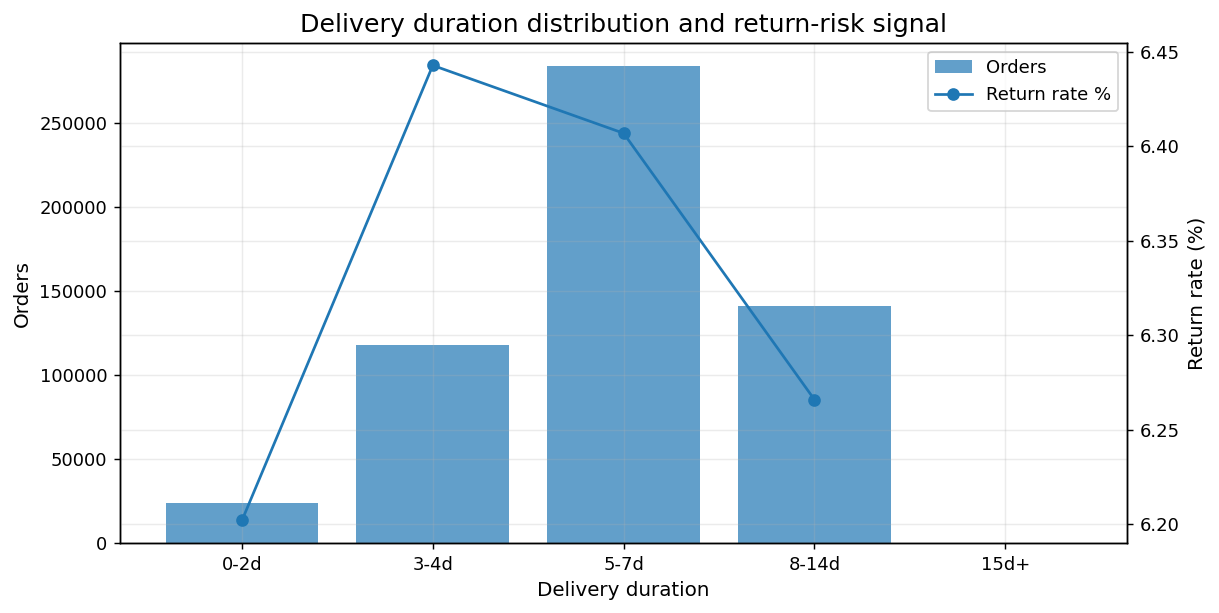

,delivery_bin,orders,revenue,return_rate,avg_rating,return_rate_%
0,0-2d,23670,"573,393,185.36",0.06,3.95,6.20
1,3-4d,117931,"2,847,961,922.43",0.06,3.94,6.44
2,5-7d,283416,"6,863,771,973.67",0.06,3.94,6.41
3,8-14d,141050,"3,425,553,890.65",0.06,3.93,6.27
4,15d+,0,0.00,NaN,NaN,NaN


In [207]:
# Delivery-day bins for service diagnostics
delivery_bins = [-1, 2, 4, 7, 14, 999]
delivery_labels = ['0-2d', '3-4d', '5-7d', '8-14d', '15d+']
orders_master['delivery_bin'] = pd.cut(orders_master['delivery_days'], bins=delivery_bins, labels=delivery_labels)

delivery = orders_master.groupby('delivery_bin').agg(
    orders=('order_id', 'count'),
    revenue=('net_revenue', 'sum'),
    return_rate=('has_return', 'mean'),
    avg_rating=('avg_rating', 'mean')
).reset_index()
delivery['return_rate_%'] = delivery['return_rate'] * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(delivery['delivery_bin'].astype(str), delivery['orders'], alpha=0.70, label='Orders')
ax1.set_ylabel('Orders')
ax1.set_xlabel('Delivery duration')
ax1.set_title('Delivery duration distribution and return-risk signal')
ax2 = ax1.twinx()
ax2.plot(delivery['delivery_bin'].astype(str), delivery['return_rate_%'], marker='o', label='Return rate %')
ax2.set_ylabel('Return rate (%)')
lines, labels_ = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_ + labels2, loc='best')
plt.show()

display(delivery.round(2))

In [208]:
top_region = region.iloc[0]
insight_box(
    'Insight 7 — Geography should drive fulfillment planning, not just sales reporting',
    'The geography section compares region/city revenue, delivery speed, return rate, and margin.',
    [
        f'{top_region.region} contributes about {top_region["revenue_share_%"]:.1f}% of net revenue, making it the main regional demand base.',
        'Average delivery time is close to 6 days, which is acceptable as a network average but still needs regional SLA monitoring.',
        'The largest cities should be treated as operational priority zones because small improvements there affect a large revenue base.'
    ],
    [
        'The business should not use a single national logistics rule. High-demand regions need different stock positioning and courier SLAs.',
        'For Vietnamese ecommerce, regional density can be used to improve delivery reliability and reduce failed deliveries.'
    ],
    [
        'Create regional SLA dashboards: delivery days, failed delivery/cancellation, returns, and refund value.',
        'Pre-position Q2 inventory in high-demand regions before April.',
        'Use city-level demand concentration to negotiate courier capacity and prioritize warehouse dispatch rules.'
    ]
)

### Insight 7 — Geography should drive fulfillment planning, not just sales reporting

**What the chart shows:** The geography section compares region/city revenue, delivery speed, return rate, and margin.

**Key findings:**
- East contributes about 46.5% of net revenue, making it the main regional demand base.
- Average delivery time is close to 6 days, which is acceptable as a network average but still needs regional SLA monitoring.
- The largest cities should be treated as operational priority zones because small improvements there affect a large revenue base.

**Business implications:**
- The business should not use a single national logistics rule. High-demand regions need different stock positioning and courier SLAs.
- For Vietnamese ecommerce, regional density can be used to improve delivery reliability and reduce failed deliveries.

**Recommended actions:**
- Create regional SLA dashboards: delivery days, failed delivery/cancellation, returns, and refund value.
- Pre-position Q2 inventory in high-demand regions before April.
- Use city-level demand concentration to negotiate courier capacity and prioritize warehouse dispatch rules.


## 11. Inventory health: stockout versus overstock trade-off

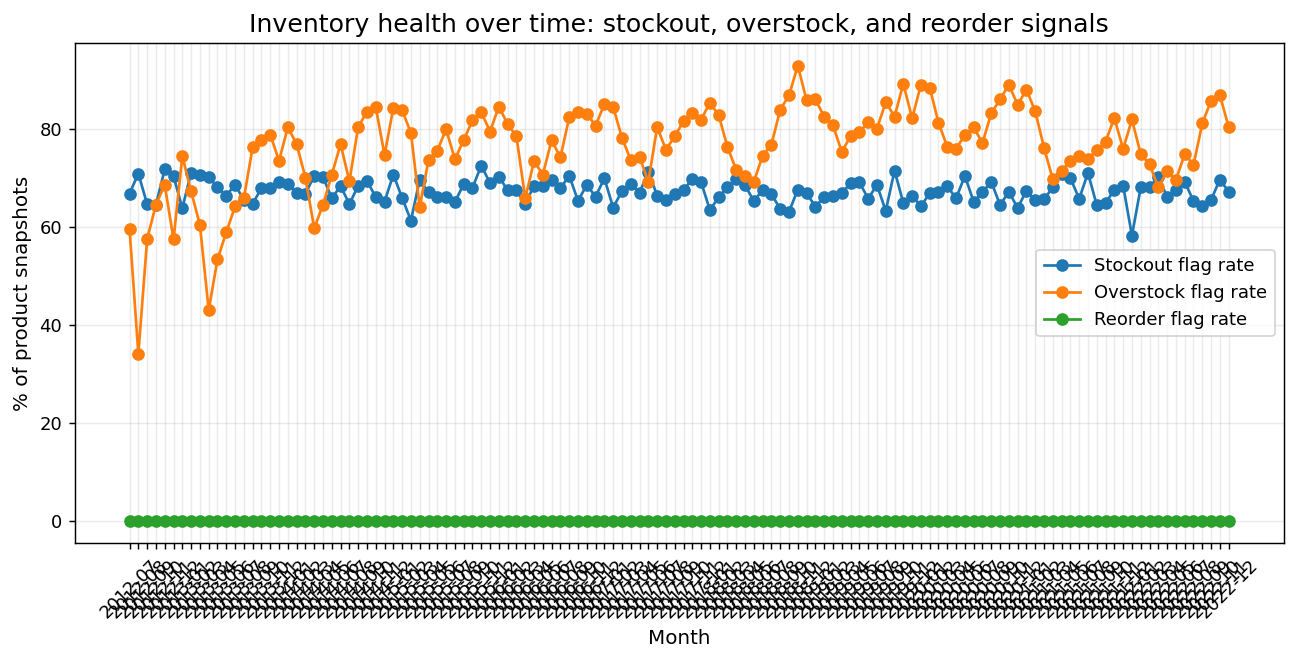

,year_month,stock_on_hand,units_received,units_sold,stockout_days,avg_fill_rate,stockout_rate,overstock_rate,reorder_rate,sell_through_rate
0,2012-07,23698,8796,7451,402,0.97,0.67,0.59,0.00,0.24
1,2012-08,26249,11799,9983,699,0.94,0.71,0.34,0.00,0.29
2,2012-09,27519,8552,7303,636,0.95,0.65,0.57,0.00,0.24
3,2012-10,29194,7732,6622,621,0.95,0.65,0.65,0.00,0.22
4,2012-11,30134,7276,6251,495,0.96,0.72,0.69,0.00,0.20
...,...,...,...,...,...,...,...,...,...,...
121,2022-08,104884,5499,4772,481,0.96,0.65,0.73,0.00,0.14
122,2022-09,107309,3868,3360,415,0.97,0.64,0.81,0.00,0.12
123,2022-10,104255,3309,2908,469,0.96,0.66,0.86,0.00,0.11
124,2022-11,95003,2649,2332,452,0.96,0.70,0.87,0.00,0.10


In [209]:
inv = inventory.copy()
inv['snapshot_date'] = pd.to_datetime(inv['snapshot_date'], errors='coerce')
inv['year_month'] = inv['snapshot_date'].dt.to_period('M').astype(str)

inv_month = inv.groupby('year_month').agg(
    stock_on_hand=('stock_on_hand', 'sum'),
    units_received=('units_received', 'sum'),
    units_sold=('units_sold', 'sum'),
    stockout_days=('stockout_days', 'sum'),
    avg_fill_rate=('fill_rate', 'mean'),
    stockout_rate=('stockout_flag', 'mean'),
    overstock_rate=('overstock_flag', 'mean'),
    reorder_rate=('reorder_flag', 'mean'),
    sell_through_rate=('sell_through_rate', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(inv_month['year_month'], inv_month['stockout_rate'] * 100, marker='o', label='Stockout flag rate')
ax.plot(inv_month['year_month'], inv_month['overstock_rate'] * 100, marker='o', label='Overstock flag rate')
ax.plot(inv_month['year_month'], inv_month['reorder_rate'] * 100, marker='o', label='Reorder flag rate')
ax.set_title('Inventory health over time: stockout, overstock, and reorder signals')
ax.set_xlabel('Month')
ax.set_ylabel('% of product snapshots')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.show()

display(inv_month.round(3))

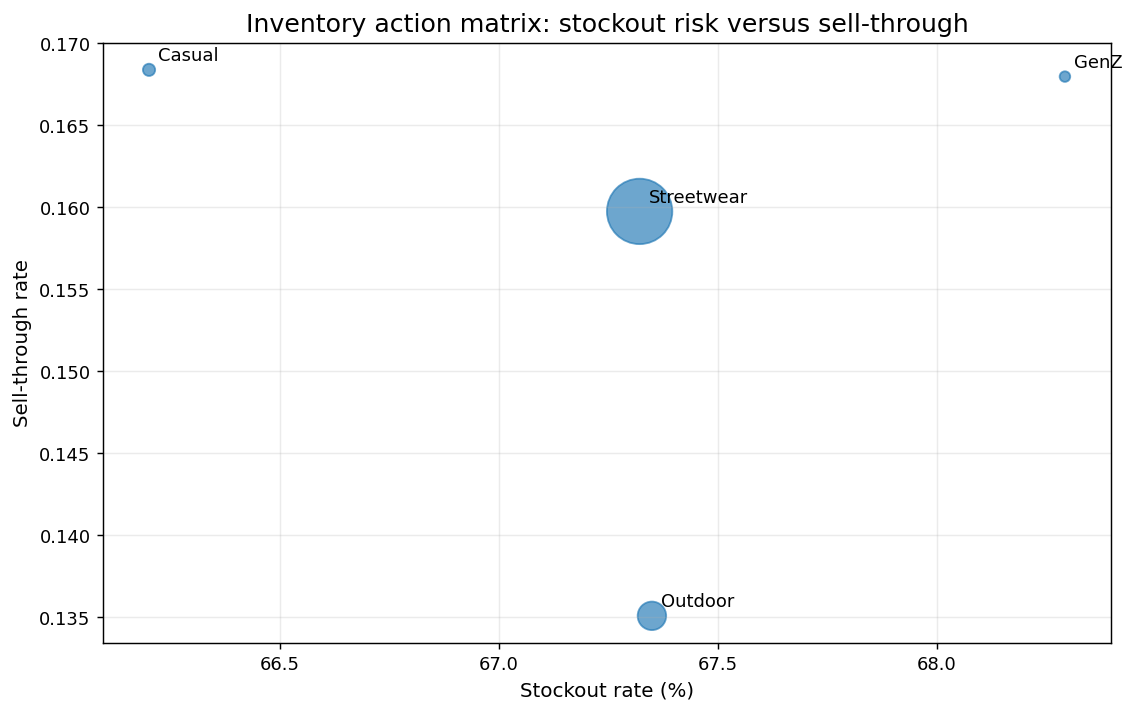

,category,stockout_rate,overstock_rate,reorder_rate,sell_through_rate,stockout_days,stock_on_hand,units_sold,revenue,stockout_rate_%,overstock_rate_%
0,Casual,0.66,0.73,0.00,0.17,4012,310522,31202,"460,648,383.35",66.20,72.59
1,GenZ,0.68,0.72,0.00,0.17,5368,584757,48695,"343,599,095.36",68.29,71.63
2,Outdoor,0.67,0.80,0.00,0.14,23552,4749891,337510,"2,494,882,754.20",67.35,79.85
3,Streetwear,0.67,0.75,0.00,0.16,36993,5759494,511467,"13,131,346,352.62",67.32,74.93


In [210]:
inv_cat = inv.groupby('category').agg(
    stockout_rate=('stockout_flag', 'mean'),
    overstock_rate=('overstock_flag', 'mean'),
    reorder_rate=('reorder_flag', 'mean'),
    sell_through_rate=('sell_through_rate', 'mean'),
    stockout_days=('stockout_days', 'sum'),
    stock_on_hand=('stock_on_hand', 'sum'),
    units_sold=('units_sold', 'sum')
).reset_index()

# Add revenue by category for priority sizing
cat_rev = items.groupby('category').agg(revenue=('gross_revenue', 'sum')).reset_index()
inv_cat = inv_cat.merge(cat_rev, on='category', how='left')
inv_cat['stockout_rate_%'] = inv_cat['stockout_rate'] * 100
inv_cat['overstock_rate_%'] = inv_cat['overstock_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(inv_cat['stockout_rate_%'], inv_cat['sell_through_rate'], s=inv_cat['revenue']/1e7, alpha=0.65)
for _, r in inv_cat.iterrows():
    ax.annotate(r['category'], (r['stockout_rate_%'], r['sell_through_rate']), fontsize=10, xytext=(5, 5), textcoords='offset points')
ax.set_title('Inventory action matrix: stockout risk versus sell-through')
ax.set_xlabel('Stockout rate (%)')
ax.set_ylabel('Sell-through rate')
plt.show()

display(inv_cat.round(3))

In [211]:
stockout_priority = inv_cat.sort_values(['stockout_rate_%', 'revenue'], ascending=False).iloc[0]
insight_box(
    'Insight 8 — Inventory should be managed by demand criticality, not only stock count',
    'The inventory charts compare stockout, overstock, reorder, sell-through, and category revenue importance.',
    [
        f'{stockout_priority.category} shows the highest stockout-priority profile when combining stockout rate and revenue importance.',
        'Stockout and overstock can coexist: this means the business may have the wrong inventory in the wrong products, sizes, regions, or months.',
        'Because Q2 demand is highly seasonal, stock availability before April matters more than average annual inventory health.'
    ],
    [
        'Inventory planning should shift from static stock monitoring to demand-aware replenishment.',
        'High-stockout, high-sell-through categories are potential lost revenue; high-overstock, low-sell-through categories are cash tied up in weak inventory.'
    ],
    [
        'Classify SKUs into four groups: protect, replenish, liquidate, and monitor.',
        'Tie Q2 forecasting output from Part 3 directly into purchasing and warehouse allocation.',
        'Create weekly pre-season alerts for high-demand SKUs with stockout flags or low days-of-supply.'
    ]
)

### Insight 8 — Inventory should be managed by demand criticality, not only stock count

**What the chart shows:** The inventory charts compare stockout, overstock, reorder, sell-through, and category revenue importance.

**Key findings:**
- GenZ shows the highest stockout-priority profile when combining stockout rate and revenue importance.
- Stockout and overstock can coexist: this means the business may have the wrong inventory in the wrong products, sizes, regions, or months.
- Because Q2 demand is highly seasonal, stock availability before April matters more than average annual inventory health.

**Business implications:**
- Inventory planning should shift from static stock monitoring to demand-aware replenishment.
- High-stockout, high-sell-through categories are potential lost revenue; high-overstock, low-sell-through categories are cash tied up in weak inventory.

**Recommended actions:**
- Classify SKUs into four groups: protect, replenish, liquidate, and monitor.
- Tie Q2 forecasting output from Part 3 directly into purchasing and warehouse allocation.
- Create weekly pre-season alerts for high-demand SKUs with stockout flags or low days-of-supply.


## 12. Customer lifecycle: retention and value segmentation

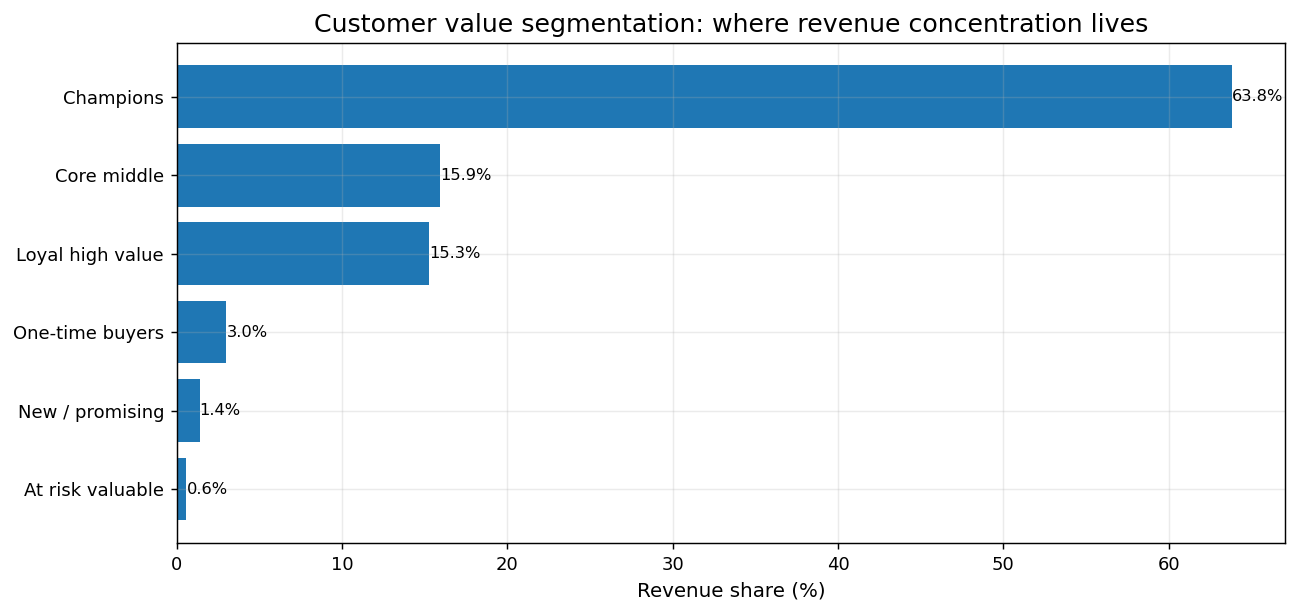

,segment,customers,revenue,margin,avg_frequency,avg_recency_days,return_rate,customer_share_%,revenue_share_%,margin_%
1,Champions,23423,"10,011,603,350.91","934,734,286.15",17.16,259.96,5.55,25.95,63.85,9.34
2,Core middle,32181,"2,494,613,604.68","228,168,442.27",3.55,"1,392.56",5.55,35.66,15.91,9.15
3,Loyal high value,8679,"2,394,162,644.50","241,611,821.20",11.10,"1,174.96",5.62,9.62,15.27,10.09
5,One-time buyers,20128,"471,554,759.27","46,644,528.50",1.00,"2,423.76",5.79,22.30,3.01,9.89
4,New / promising,4868,"217,267,251.16","14,807,276.56",1.61,341.23,5.68,5.39,1.39,6.82
0,At risk valuable,967,"91,667,654.91","7,191,357.20",6.64,"1,808.50",5.61,1.07,0.58,7.85


In [212]:
# Customer-level RFM
snapshot_date = orders_master['order_date'].max() + pd.Timedelta(days=1)
rfm = orders_master.groupby('customer_id').agg(
    last_order=('order_date', 'max'),
    first_order=('order_date', 'min'),
    frequency=('order_id', 'count'),
    revenue=('net_revenue', 'sum'),
    margin=('gross_margin', 'sum'),
    refunds=('refund_amount', 'sum'),
    returns=('has_return', 'sum')
).reset_index()
rfm['recency_days'] = (snapshot_date - rfm['last_order']).dt.days
rfm['return_rate_%'] = rfm['returns'] / rfm['frequency'] * 100
rfm['margin_%'] = rfm['margin'] / rfm['revenue'] * 100

# Quantile-safe scoring
rfm['r_score'] = pd.qcut(rfm['recency_days'].rank(method='first'), 5, labels=[5,4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['revenue'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

def segment_customer(row):
    if row['r_score'] >= 4 and row['f_score'] >= 4 and row['m_score'] >= 4:
        return 'Champions'
    if row['f_score'] >= 4 and row['m_score'] >= 4:
        return 'Loyal high value'
    if row['r_score'] >= 4 and row['f_score'] <= 2:
        return 'New / promising'
    if row['r_score'] <= 2 and row['f_score'] >= 4:
        return 'At risk valuable'
    if row['frequency'] == 1:
        return 'One-time buyers'
    return 'Core middle'

rfm['segment'] = rfm.apply(segment_customer, axis=1)
seg = rfm.groupby('segment').agg(
    customers=('customer_id', 'count'),
    revenue=('revenue', 'sum'),
    margin=('margin', 'sum'),
    avg_frequency=('frequency', 'mean'),
    avg_recency_days=('recency_days', 'mean'),
    return_rate=('return_rate_%', 'mean')
).reset_index()
seg['customer_share_%'] = seg['customers'] / seg['customers'].sum() * 100
seg['revenue_share_%'] = seg['revenue'] / seg['revenue'].sum() * 100
seg['margin_%'] = seg['margin'] / seg['revenue'] * 100
seg = seg.sort_values('revenue', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(seg['segment'][::-1], seg['revenue_share_%'][::-1])
ax.set_title('Customer value segmentation: where revenue concentration lives')
ax.set_xlabel('Revenue share (%)')
for i, v in enumerate(seg['revenue_share_%'][::-1]):
    ax.text(v, i, f'{v:.1f}%', va='center', fontsize=9)
plt.show()

display(seg.round(2))

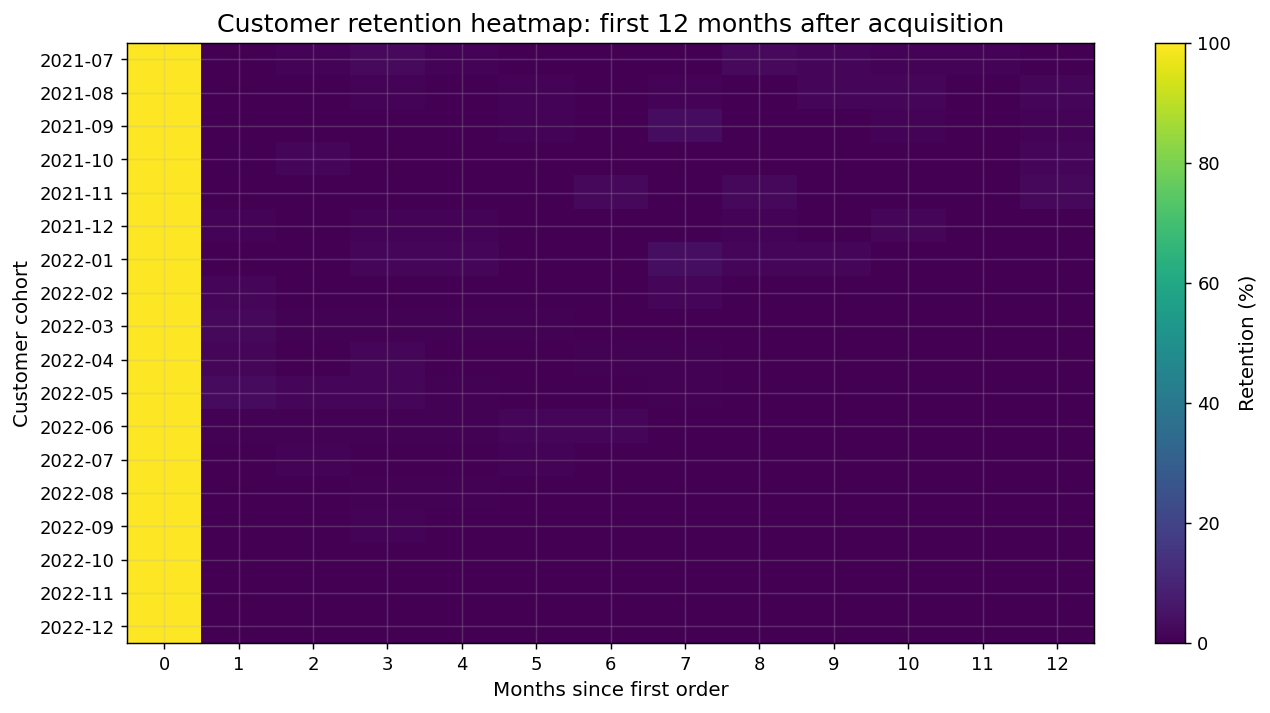

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2021-07,100.00,NaN,0.80,2.50,0.80,NaN,NaN,NaN,2.50,1.60,0.80,0.80,NaN
2021-08,100.00,NaN,NaN,0.80,NaN,0.80,NaN,0.80,NaN,1.60,1.60,NaN,1.60
2021-09,100.00,NaN,NaN,NaN,NaN,1.10,NaN,3.40,NaN,NaN,1.10,NaN,1.10
2021-10,100.00,NaN,1.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.70
2021-11,100.00,NaN,NaN,NaN,NaN,NaN,2.20,NaN,2.20,NaN,NaN,NaN,2.20


In [213]:
# Cohort retention matrix based on first order month.
cohort_data = orders_master[['customer_id', 'order_date']].dropna().copy()
cohort_data['order_month'] = cohort_data['order_date'].dt.to_period('M')
first_month = cohort_data.groupby('customer_id')['order_month'].min().rename('cohort_month')
cohort_data = cohort_data.merge(first_month, on='customer_id')
cohort_data['period_number'] = (cohort_data['order_month'].dt.year - cohort_data['cohort_month'].dt.year) * 12 + (cohort_data['order_month'].dt.month - cohort_data['cohort_month'].dt.month)
# Show recent cohorts with enough history; cap to first 12 months.
cohort_counts = cohort_data[cohort_data['period_number'].between(0, 12)].groupby(['cohort_month', 'period_number'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index='cohort_month', columns='period_number', values='customer_id')
cohort_sizes = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100
# Use last 18 cohorts to keep visual readable.
retention_display = retention.tail(18)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(retention_display.fillna(0).values, aspect='auto', vmin=0)
ax.set_title('Customer retention heatmap: first 12 months after acquisition')
ax.set_xlabel('Months since first order')
ax.set_ylabel('Customer cohort')
ax.set_xticks(range(len(retention_display.columns)), labels=retention_display.columns)
ax.set_yticks(range(len(retention_display.index)), labels=[str(x) for x in retention_display.index])
plt.colorbar(im, ax=ax, label='Retention (%)')
plt.show()

retention_display.round(1).head()

In [214]:
champ = seg[seg['segment'].eq('Champions')]
if len(champ):
    champ = champ.iloc[0]
else:
    champ = seg.iloc[0]

at_risk = seg[seg['segment'].str.contains('At risk', case=False, na=False)]
at_risk = at_risk.iloc[0] if len(at_risk) else seg.iloc[-1]

insight_box(
    'Insight 9 — Retention is a hidden profit lever',
    'The RFM and cohort charts show how revenue concentrates across customer lifecycle groups and how quickly cohorts decay after acquisition.',
    [
        f'{champ.segment} represent {champ["customer_share_%"]:.1f}% of customers but contribute {champ["revenue_share_%"]:.1f}% of revenue.',
        f'{at_risk.segment} still represents roughly {at_risk["revenue_share_%"]:.1f}% of revenue and should not be allowed to lapse silently.',
        'The cohort heatmap makes retention visible as an operating metric, not just a marketing metric.'
    ],
    [
        'The firm can grow revenue without only buying new traffic by converting promising customers into repeat buyers and reactivating at-risk valuable customers.',
        'In Vietnamese fashion ecommerce, repeated seasonal purchase moments are predictable: Tet, spring/summer refresh, mid-year sales, back-to-school, and year-end.'
    ],
    [
        'Build lifecycle journeys: first-order onboarding, second-order incentive, Q2 seasonal refresh, and win-back before major campaigns.',
        'Personalize recommendations by category and size history to reduce return risk.',
        'Track retention by acquisition channel so paid acquisition is judged by downstream value, not first order only.'
    ]
)

### Insight 9 — Retention is a hidden profit lever

**What the chart shows:** The RFM and cohort charts show how revenue concentrates across customer lifecycle groups and how quickly cohorts decay after acquisition.

**Key findings:**
- Champions represent 26.0% of customers but contribute 63.8% of revenue.
- At risk valuable still represents roughly 0.6% of revenue and should not be allowed to lapse silently.
- The cohort heatmap makes retention visible as an operating metric, not just a marketing metric.

**Business implications:**
- The firm can grow revenue without only buying new traffic by converting promising customers into repeat buyers and reactivating at-risk valuable customers.
- In Vietnamese fashion ecommerce, repeated seasonal purchase moments are predictable: Tet, spring/summer refresh, mid-year sales, back-to-school, and year-end.

**Recommended actions:**
- Build lifecycle journeys: first-order onboarding, second-order incentive, Q2 seasonal refresh, and win-back before major campaigns.
- Personalize recommendations by category and size history to reduce return risk.
- Track retention by acquisition channel so paid acquisition is judged by downstream value, not first order only.


## 13. Predictive EDA: leading indicators and next-season risk signals

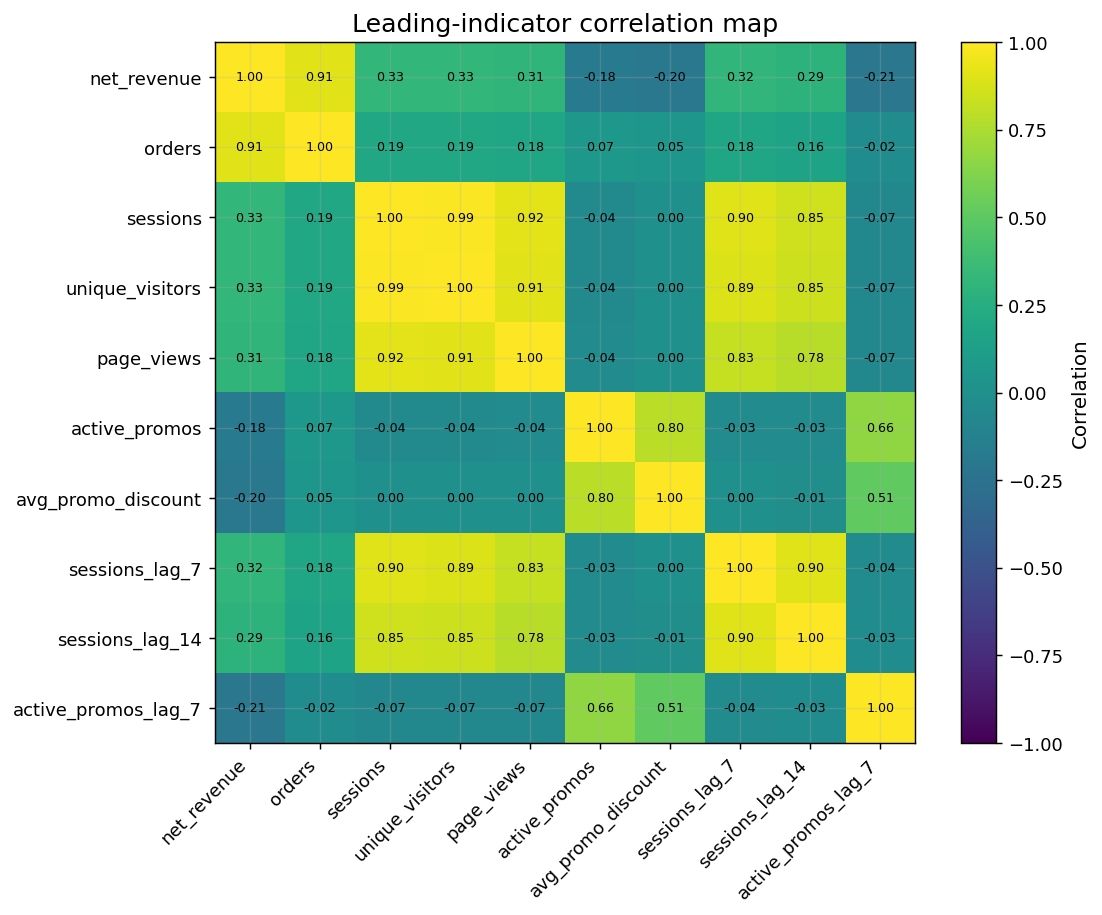

net_revenue            1.00
orders                 0.91
sessions               0.33
unique_visitors        0.33
sessions_lag_7         0.32
page_views             0.31
sessions_lag_14        0.29
active_promos         -0.18
avg_promo_discount    -0.20
active_promos_lag_7   -0.21
Name: net_revenue, dtype: float64

In [215]:
# Merge daily signals for leading indicator exploration.
daily = daily_orders.merge(daily_traffic, on='date', how='left')
daily = daily.sort_values('date')

# Add promotion intensity by day
if 'promo_calendar' in globals() and len(promo_calendar):
    promo_day = promo_calendar.groupby('date').agg(
        active_promos=('promo_id', 'nunique'),
        avg_promo_discount=('discount_value', 'mean')
    ).reset_index()
    daily = daily.merge(promo_day, on='date', how='left')
else:
    daily['active_promos'] = 0
    daily['avg_promo_discount'] = 0

daily[['active_promos', 'avg_promo_discount']] = daily[['active_promos', 'avg_promo_discount']].fillna(0)

# Lagged traffic and promo signals
for lag in [1, 7, 14, 28]:
    daily[f'sessions_lag_{lag}'] = daily['sessions'].shift(lag)
    daily[f'active_promos_lag_{lag}'] = daily['active_promos'].shift(lag)

daily['revenue_7d_ma'] = daily['net_revenue'].rolling(7).mean()
daily['sessions_7d_ma'] = daily['sessions'].rolling(7).mean()

indicator_cols = ['net_revenue', 'orders', 'sessions', 'unique_visitors', 'page_views', 'active_promos', 'avg_promo_discount', 'sessions_lag_7', 'sessions_lag_14', 'active_promos_lag_7']
indicator_corr = daily[indicator_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(indicator_corr.values, vmin=-1, vmax=1)
ax.set_title('Leading-indicator correlation map')
ax.set_xticks(range(len(indicator_corr.columns)), labels=indicator_corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(indicator_corr.index)), labels=indicator_corr.index)
for i in range(len(indicator_corr.index)):
    for j in range(len(indicator_corr.columns)):
        ax.text(j, i, f'{indicator_corr.values[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, label='Correlation')
plt.show()

indicator_corr['net_revenue'].sort_values(ascending=False).round(3)

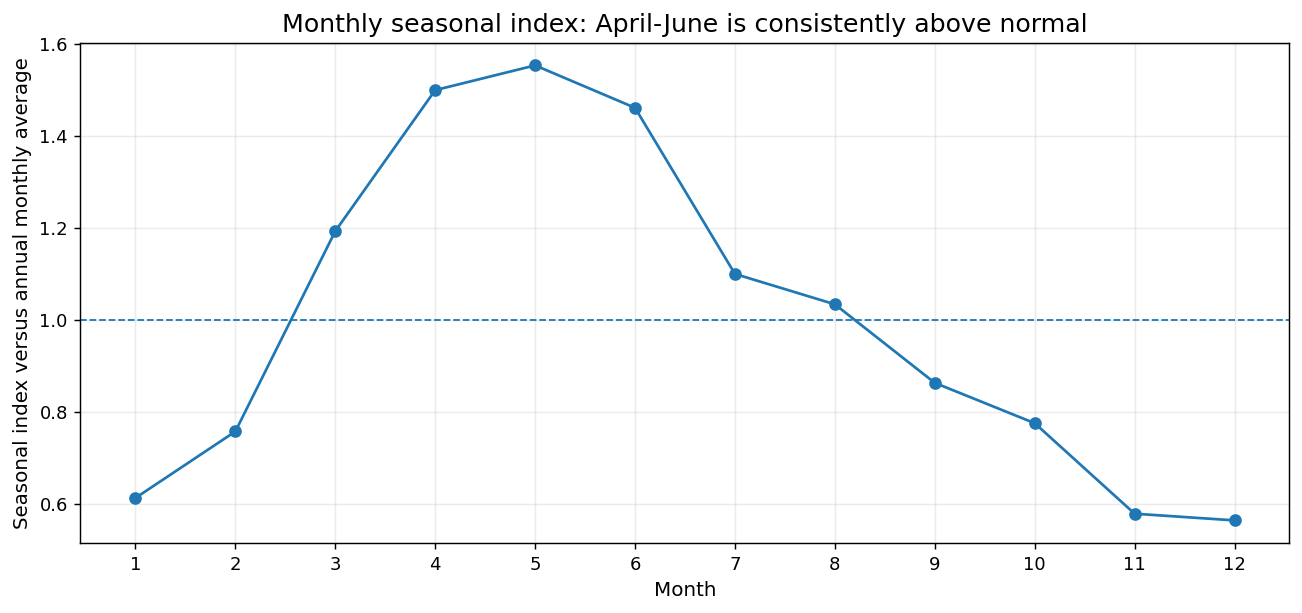

,month,avg_seasonal_index,avg_revenue
0,1,0.61,"80,325,792.74"
1,2,0.76,"98,158,581.94"
2,3,1.19,"152,773,749.67"
3,4,1.50,"195,988,556.46"
4,5,1.55,"203,837,906.83"
5,6,1.46,"192,813,259.57"
6,7,1.10,"144,460,203.51"
7,8,1.03,"135,535,773.98"
8,9,0.86,"112,397,531.47"
9,10,0.78,"101,604,360.53"


In [216]:
# Seasonal index and operating calendar
monthly = calendar_full_years.groupby(['year', 'month']).agg(revenue=('revenue', 'sum')).reset_index()
monthly['year_avg_monthly_revenue'] = monthly.groupby('year')['revenue'].transform('mean')
monthly['seasonal_index'] = monthly['revenue'] / monthly['year_avg_monthly_revenue']
seasonality = monthly.groupby('month').agg(
    avg_seasonal_index=('seasonal_index', 'mean'),
    avg_revenue=('revenue', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(seasonality['month'], seasonality['avg_seasonal_index'], marker='o')
ax.axhline(1, ls='--', lw=1)
ax.set_title('Monthly seasonal index: April-June is consistently above normal')
ax.set_xlabel('Month')
ax.set_ylabel('Seasonal index versus annual monthly average')
ax.set_xticks(range(1, 13))
plt.show()

display(seasonality.round(3))

In [217]:
# A simple predictive operating calendar: combine seasonal index with promo windows and inventory actions.
seasonality['business_read'] = np.select(
    [seasonality['avg_seasonal_index'] >= 1.25, seasonality['avg_seasonal_index'] >= 1.05, seasonality['avg_seasonal_index'] <= 0.85],
    ['Peak demand', 'Above normal', 'Low season'],
    default='Normal'
)
seasonality['recommended_action'] = seasonality['business_read'].map({
    'Peak demand': 'Protect stock, delivery SLA, and margin. Avoid excessive discounting.',
    'Above normal': 'Scale campaigns and monitor stockout risk.',
    'Normal': 'Optimize assortment and test targeted campaigns.',
    'Low season': 'Use retention, clearance, and margin-safe bundles.'
})

display(seasonality[['month', 'avg_seasonal_index', 'business_read', 'recommended_action']].round(2))

,month,avg_seasonal_index,business_read,recommended_action
0,1,0.61,Low season,"Use retention, clearance, and margin-safe bund..."
1,2,0.76,Low season,"Use retention, clearance, and margin-safe bund..."
2,3,1.19,Above normal,Scale campaigns and monitor stockout risk.
3,4,1.50,Peak demand,"Protect stock, delivery SLA, and margin. Avoid..."
4,5,1.55,Peak demand,"Protect stock, delivery SLA, and margin. Avoid..."
5,6,1.46,Peak demand,"Protect stock, delivery SLA, and margin. Avoid..."
6,7,1.10,Above normal,Scale campaigns and monitor stockout risk.
7,8,1.03,Normal,Optimize assortment and test targeted campaigns.
8,9,0.86,Normal,Optimize assortment and test targeted campaigns.
9,10,0.78,Low season,"Use retention, clearance, and margin-safe bund..."


In [218]:
top_month = seasonality.sort_values('avg_seasonal_index', ascending=False).iloc[0]
insight_box(
    'Insight 10 — Predictive EDA turns seasonality into an operating calendar',
    'The predictive section uses lagged traffic, promotion signals, and historical seasonality to identify which periods are likely to require management attention.',
    [
        f'Month {int(top_month.month)} has the highest seasonal index at about {top_month.avg_seasonal_index:.2f}x an average month.',
        'Traffic and order signals are strongly related to revenue, making web activity a practical leading indicator for demand planning.',
        'April-June consistently sits above normal, supporting the Q2 harvest-quarter thesis.'
    ],
    [
        'The company should operationalize EDA into a monthly planning calendar, not leave insights inside a dashboard.',
        'Forecasting from Part 3 should be used by inventory, marketing, and logistics teams before the demand wave arrives.'
    ],
    [
        'Create a monthly demand-control tower: forecast, traffic trend, stockout risk, campaign plan, fulfillment capacity.',
        'Trigger pre-season meetings in February/March for Q2, and in October for year-end campaigns.',
        'Use leading traffic signals to adjust campaign spend and warehouse staffing weekly.'
    ]
)

### Insight 10 — Predictive EDA turns seasonality into an operating calendar

**What the chart shows:** The predictive section uses lagged traffic, promotion signals, and historical seasonality to identify which periods are likely to require management attention.

**Key findings:**
- Month 5 has the highest seasonal index at about 1.55x an average month.
- Traffic and order signals are strongly related to revenue, making web activity a practical leading indicator for demand planning.
- April-June consistently sits above normal, supporting the Q2 harvest-quarter thesis.

**Business implications:**
- The company should operationalize EDA into a monthly planning calendar, not leave insights inside a dashboard.
- Forecasting from Part 3 should be used by inventory, marketing, and logistics teams before the demand wave arrives.

**Recommended actions:**
- Create a monthly demand-control tower: forecast, traffic trend, stockout risk, campaign plan, fulfillment capacity.
- Trigger pre-season meetings in February/March for Q2, and in October for year-end campaigns.
- Use leading traffic signals to adjust campaign spend and warehouse staffing weekly.


## 14. Prescriptive strategy: quantified opportunity sizing

In [219]:
# Opportunity sizing based on observed leakages.
# These are conservative directional estimates meant for business prioritization, not audited financial forecasts.

total_refund = orders_master['refund_amount'].sum()
top_return_saving_10pct = return_reason.iloc[0]['refund'] * 0.10

# Promo discount leakage: cap Q3/Q4 at Q2 discount rate + 1 percentage point.
qdisc = orders_master.groupby('quarter').agg(gross=('gross_revenue', 'sum'), discount=('discount_amount', 'sum'))
qdisc['discount_rate'] = qdisc['discount'] / qdisc['gross']
q2_plus_1pp = qdisc.loc[2, 'discount_rate'] + 0.01
discount_saving_q3q4 = sum(max(0, (qdisc.loc[q, 'discount_rate'] - q2_plus_1pp) * qdisc.loc[q, 'gross']) for q in [3, 4])

# COD cancellation exposure from earlier.
cod_name = 'cod' if 'cod' in payment[payment_col].values else payment.sort_values('cancel_rate_%', ascending=False).iloc[0][payment_col]
cod = payment[payment[payment_col].eq(cod_name)].iloc[0]
non_cod_cancel_rate = payment[~payment[payment_col].eq(cod_name)]['cancel_rate_%'].mean()
excess_cod_cancel_orders = max(0, (cod['cancel_rate_%'] - non_cod_cancel_rate) / 100 * cod['orders'])
excess_cod_cancel_value = excess_cod_cancel_orders * (cod['revenue'] / cod['orders'])

# Revenue protection in Q2: if a 1% execution improvement protects Q2 revenue.
q2_revenue = quarter[quarter['quarter'].eq(2)]['revenue'].sum()
q2_execution_1pct = q2_revenue * 0.01

opportunity = pd.DataFrame([
    {
        'priority': 1,
        'lever': 'Protect Q2 demand wave',
        'evidence': 'Q2 contributes the largest annual revenue share and strongest traffic/order volume.',
        'action': 'Pre-stock, pre-staff, and protect margin from March to June.',
        'directional_value': q2_execution_1pct,
        'risk_if_ignored': 'Lost peak-season revenue and customer dissatisfaction from stockout/delay.'
    },
    {
        'priority': 2,
        'lever': 'Promotion margin guardrails',
        'evidence': 'Promo orders show severe margin pressure; Q3/Q4 discount rates exceed Q2 benchmark.',
        'action': 'Require campaign margin forecast and cap broad markdowns.',
        'directional_value': discount_saving_q3q4,
        'risk_if_ignored': 'Revenue growth without profit growth.'
    },
    {
        'priority': 3,
        'lever': 'Reduce top return reason',
        'evidence': f'{return_reason.iloc[0].return_reason} is the largest refund driver.',
        'action': 'Improve size guide, product content, QA, and SKU-level return alerts.',
        'directional_value': top_return_saving_10pct,
        'risk_if_ignored': 'Refund leakage, low trust, repeat-purchase friction.'
    },
    {
        'priority': 4,
        'lever': 'COD risk control',
        'evidence': f'{cod_name} has materially higher cancellation risk.',
        'action': 'Risk-score COD, confirm risky orders, incentivize prepaid methods.',
        'directional_value': excess_cod_cancel_value,
        'risk_if_ignored': 'Failed delivery, wasted logistics capacity, inventory lock-up.'
    },
])

opportunity['directional_value_formatted'] = opportunity['directional_value'].apply(fmt_vnd_millions)
display(opportunity[['priority', 'lever', 'evidence', 'action', 'directional_value_formatted', 'risk_if_ignored']])

,priority,lever,evidence,action,directional_value_formatted,risk_if_ignored
0,1,Protect Q2 demand wave,Q2 contributes the largest annual revenue shar...,"Pre-stock, pre-staff, and protect margin from ...",59.3M,Lost peak-season revenue and customer dissatis...
1,2,Promotion margin guardrails,Promo orders show severe margin pressure; Q3/Q...,Require campaign margin forecast and cap broad...,175.8M,Revenue growth without profit growth.
2,3,Reduce top return reason,wrong_size is the largest refund driver.,"Improve size guide, product content, QA, and S...",17.7M,"Refund leakage, low trust, repeat-purchase fri..."
3,4,COD risk control,cod has materially higher cancellation risk.,"Risk-score COD, confirm risky orders, incentiv...",188.1M,"Failed delivery, wasted logistics capacity, in..."


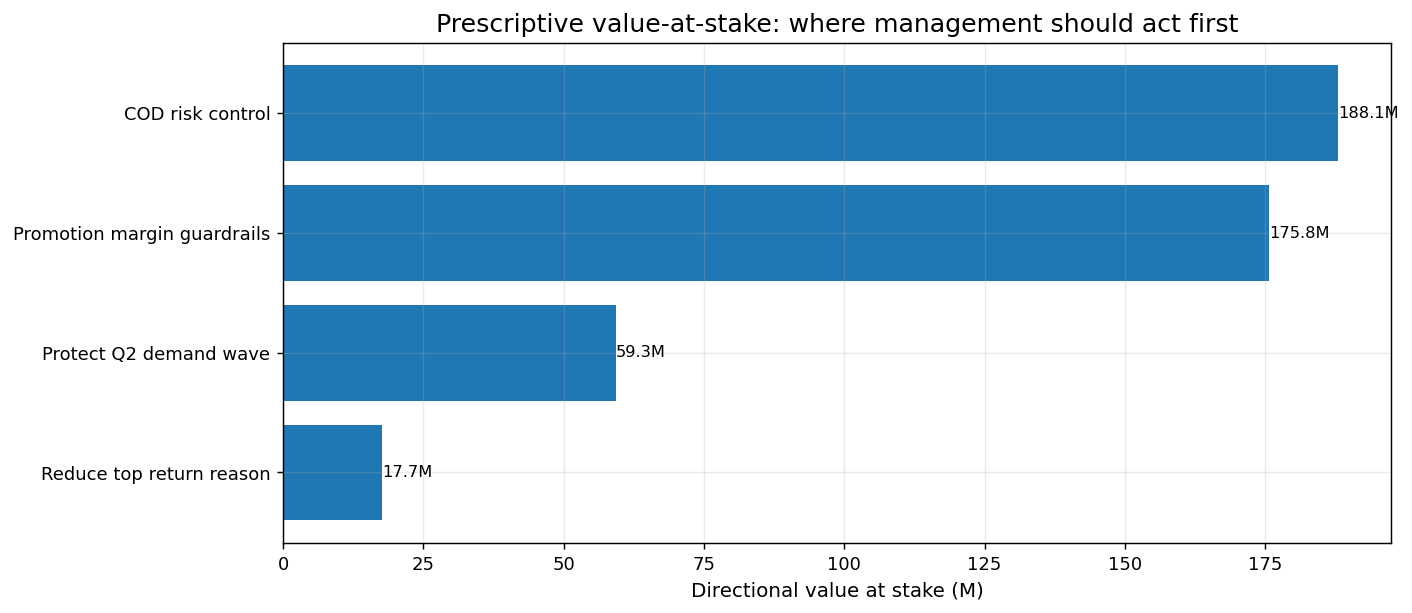

In [220]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = opportunity.sort_values('directional_value')
ax.barh(plot_df['lever'], plot_df['directional_value'] / 1e6)
ax.set_title('Prescriptive value-at-stake: where management should act first')
ax.set_xlabel('Directional value at stake (M)')
for i, v in enumerate(plot_df['directional_value'] / 1e6):
    ax.text(v, i, f'{v:,.1f}M', va='center', fontsize=9)
plt.show()

## 15. Final executive recommendation

### What happened?
The company grew strongly through the mid-2010s, then experienced a structural revenue downshift from 2019-2021, followed by partial recovery in 2022. Seasonality is not flat: **Q2 is the clear demand engine**.

### Why did it happen?
Revenue is driven by a combination of traffic, order volume, and seasonal fashion demand. The strongest demand wave is not the deepest-discount period. The problem is that value leaks after demand is captured: promotion margin erosion, returns, COD cancellations, fulfillment friction, and inventory mismatch.

### What is likely to happen?
Without intervention, Q2 will remain the biggest revenue opportunity, but the firm risks losing value through stockouts, poor delivery experience, and poor campaign discipline. Q3/Q4 may continue to require heavier discounting unless segmentation and retention improve.

### What should the firm do?
1. **Protect Q2 as the annual harvest quarter**: pre-stock, pre-staff, and campaign earlier.
2. **Control promotion profitability**: approve campaigns by margin and expected customer quality, not only revenue.
3. **Attack return leakage**: start with the largest refund reason, then expand to SKU-level quality alerts.
4. **Govern COD risk**: keep COD for accessibility, but apply risk scoring and confirmation flows.
5. **Turn Part 3 forecasting into operations**: feed forecasts into inventory, warehouse staffing, campaign spend, and regional stock allocation.